# PROYECTO DATAXPERIENCE

## Análisis de rentabilidad y riesgo de desabastecimiento
## en el sector farmacéutico colombiano durante 2025

### Integrantes

- Sara Sofía Cruz Fandiño
- Martin Felipe Diaz Collas
- Sergio David Vargas Sáenz
- Julián Fernando Gómez Escobar

## 1. Contexto del proyecto

El proyecto analiza un registro de operaciones farmacéuticas correspondiente
al año 2025 en Colombia.

El interés del análisis surge de la necesidad de comprender cómo diferentes
características de las operaciones farmacéuticas pueden relacionarse con la
rentabilidad y el riesgo de desabastecimiento.

A partir de los datos buscamos identificar patrones que puedan ser útiles
como apoyo para decisiones relacionadas con ventas, inventario y
abastecimiento.

## 2. Objetivo general

Analizar la relación entre el tipo de institución, el fabricante y la
ubicación geográfica con la rentabilidad y el riesgo de desabastecimiento
de productos farmacéuticos durante 2025, con el propósito de identificar
patrones que puedan apoyar la toma de decisiones relacionadas con ventas,
inventario y abastecimiento.

## 3. Pregunta principal

¿Cómo se relacionan el tipo de institución, el fabricante y la ubicación
geográfica con la rentabilidad y el riesgo de desabastecimiento de productos
farmacéuticos durante 2025, y qué patrones pueden apoyar la toma de decisiones
sobre ventas, inventario y abastecimiento?

## 4. Preguntas de apoyo

1. ¿Qué tipos de institución presentan mayores niveles de ventas, rentabilidad y margen bruto?

2. ¿Qué fabricantes concentran mayores niveles de ventas y cuáles presentan mejores niveles de rentabilidad?

3. ¿Qué ciudades o regiones presentan mayores niveles de ventas y rentabilidad, y cómo se relacionan con el riesgo de desabastecimiento?

4. ¿Qué relación existe entre los días de inventario, el tiempo de entrega y el riesgo de desabastecimiento?

5. ¿Qué productos o segmentos presentan una combinación de alta rentabilidad y alto riesgo de desabastecimiento que pueda ser relevante para las decisiones de ventas, inventario y abastecimiento?

## 5. Datos utilizados

Para desarrollar el proyecto utilizamos un conjunto de datos sobre operaciones del sector farmacéutico colombiano correspondientes al año 2025.

Los datos contienen información relacionada con las ventas, los productos, los fabricantes, las instituciones, la ubicación geográfica, la rentabilidad y diferentes variables asociadas al inventario y al riesgo de desabastecimiento.

### 5.1 Fuente de los datos

El análisis se realiza a partir del dataset farmacéutico proporcionado para el desarrollo del proyecto. La información corresponde a registros del mercado farmacéutico colombiano durante el año 2025.

### 5.2 Descripción del dataset

Cada registro representa una operación o registro relacionado con un producto farmacéutico. El conjunto de datos permite analizar diferentes aspectos del comportamiento comercial y del abastecimiento.

Entre las variables disponibles se encuentran datos relacionados con:

- Producto y fabricante.
- Tipo de institución.
- Ciudad y región.
- Fecha y periodo de la operación.
- Ventas netas.
- Precio unitario.
- Utilidad bruta.
- Margen bruto.
- Días de inventario.
- Tiempo de entrega.
- Riesgo de desabastecimiento.

### 5.3 Variables relevantes para el proyecto

Para responder la pregunta principal, nos enfocaremos principalmente en las variables que permiten relacionar las características de las operaciones con la rentabilidad y el riesgo de desabastecimiento.

| Dimensión | Variables de interés |
|---|---|
| Institución | Tipo de institución |
| Fabricante | Fabricante |
| Ubicación | Ciudad, Región |
| Ventas | Ventas netas, Unidades |
| Rentabilidad | Utilidad bruta, Margen bruto |
| Inventario | Inventario en días |
| Abastecimiento | Lead time en días |
| Riesgo | Riesgo de stockout |
| Tiempo | Fecha, Mes |

Estas variables serán utilizadas durante las siguientes etapas para explorar los datos, identificar patrones y analizar posibles relaciones que puedan apoyar decisiones sobre ventas, inventario y abastecimiento.

## 6. Carga y revisión inicial de los datos

Antes de realizar cualquier proceso de limpieza, se realiza una revisión inicial del conjunto de datos. El propósito de esta etapa es conocer su estructura y detectar posibles problemas que puedan afectar el análisis posterior.

En esta revisión se analizarán las dimensiones del dataset, los tipos de datos, los valores faltantes, los registros duplicados y algunas características de las variables categóricas y numéricas.

Esta etapa se realiza sobre los datos **crudos**, es decir, antes de aplicar cualquier modificación.

### 6.1 Carga del dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargamos el dataset original
df = pd.read_csv(
    'dataset_farmaceutico.csv',
    encoding='UTF-8-SIG',
    sep=';'
)

# Creamos una copia que utilizaremos posteriormente para la limpieza
df_limpio = df.copy()

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


### 6.2 Dimensiones del dataset

Primero revisamos cuántos registros y variables contiene el dataset antes de realizar cualquier proceso de limpieza.

In [ ]:
print(f"Cantidad de registros: {df.shape[0]}")
print(f"Cantidad de variables: {df.shape[1]}")

Cantidad de registros: 5075
Cantidad de variables: 33


### 6.3 Estructura y tipos de datos

Revisamos los nombres de las variables, sus tipos de datos y la cantidad de valores no nulos. Esto permite identificar variables que puedan requerir una transformación antes del análisis.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5075 entries, 0 to 5074
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Registro            5075 non-null   object 
 1   Fecha                  5075 non-null   object 
 2   Año                    5075 non-null   int64  
 3   Mes_Num                5075 non-null   int64  
 4   Mes                    5075 non-null   object 
 5   Trimestre              5075 non-null   object 
 6   Región                 5069 non-null   object 
 7   Ciudad                 5068 non-null   object 
 8   Tipo_Institución       5075 non-null   object 
 9   Institución            5064 non-null   object 
 10  Canal                  5075 non-null   object 
 11  Línea_Terapéutica      5075 non-null   object 
 12  Producto               5072 non-null   object 
 13  Fabricante             5065 non-null   object 
 14  Unidad_Medida          5075 non-null   object 
 15  Requ

### 6.4 Visualización inicial de los datos

Observamos algunos registros del dataset para conocer cómo están organizados los datos y detectar posibles inconsistencias de forma preliminar.

In [ ]:
df.head()

,ID_Registro,Fecha,Año,Mes_Num,Mes,Trimestre,Región,Ciudad,Tipo_Institución,Institución,...,Pacientes_Impactados,Urgencia_Abasto,Ventas_Brutas_USD,Monto_Descuento_USD,Ventas_Netas_USD,Costo_Total_USD,Utilidad_Bruta_USD,Margen_Bruto_Pct,Devoluciones_Unidades,Riesgo_Stockout
0,RX-00001,2025-06-15 00:00:00,2025,6,Jun,T2,Sur,Pasto,Cadena de Farmacias,Farmatodo,...,46.0,Baja,"163,89","4,621698","159,268302","76,95","82,318302","0,516853014",0,"0,129375"
1,RX-00002,2025-07-07 00:00:00,2025,7,Jul,T3,Occidente,Pereira,Hospital,Clínica Comfamiliar Risaralda,...,38.0,Baja,"356,85","28,47663","328,37337","186,3","142,07337","0,432658014",0,"0,136644737"
2,RX-00003,2025-05-04 00:00:00,2025,5,May,T2,Norte,Santa Marta,Hospital,Hospital Universitario Julio Méndez Barreneche,...,28.0,Baja,"313,04","32,806592","280,233408","165,88","114,353408","0,408064866",0,"0,186293103"
3,RX-00004,2025-11-18 00:00:00,2025,11,Nov,T4,Occidente,Medellín,Cadena de Farmacias,Droguerías Colsubsidio,...,8.0,Baja,"87,89","4,148408","83,741592","52,03","31,711592","0,378683892",0,"0,137933333"
4,RX-00005,2025-01-24 00:00:00,2025,1,Jan,T1,Occidente,Medellín,Clínica,Hospital Pablo Tobón Uribe,...,1.0,Baja,"920,99","107,295335","813,694665","804,44","9,254665","0,011373634",0,"0,106307692"


### 6.5 Valores faltantes

Revisamos la cantidad de valores faltantes presentes en cada variable. Esta información será utilizada posteriormente para determinar si es necesario realizar algún tratamiento durante la limpieza.

In [ ]:
valores_faltantes = df.isnull().sum()

valores_faltantes[valores_faltantes > 0].sort_values(ascending=False)

,0
Institución,11
Fabricante,10
Ciudad,7
Región,6
Pacientes_Impactados,6
Urgencia_Abasto,6
Precio_Unitario_USD,5
Unidades,5
Producto,3
Descuento_Pct,2


### 6.6 Registros duplicados

Verificamos si existen registros duplicados dentro del dataset. Los duplicados pueden generar un conteo incorrecto de las operaciones y afectar cálculos como las ventas y la rentabilidad.

In [ ]:
duplicados = df.duplicated().sum()

print(f"Cantidad de registros duplicados: {duplicados}")

Cantidad de registros duplicados: 50


### 6.7 Revisión del identificador de los registros

Además de revisar duplicados completos, verificamos si existen identificadores repetidos en `ID_Registro`. Esta revisión permite determinar si un mismo registro aparece más de una vez y si será necesario realizar una limpieza específica.

In [ ]:
duplicados_id = df["ID_Registro"].duplicated().sum()

print(f"Cantidad de ID_Registro repetidos: {duplicados_id}")

Cantidad de ID_Registro repetidos: 50


Para conocer cuales son:

In [ ]:
df[df["ID_Registro"].duplicated(keep=False)].sort_values("ID_Registro").head(20)

,ID_Registro,Fecha,Año,Mes_Num,Mes,Trimestre,Región,Ciudad,Tipo_Institución,Institución,...,Pacientes_Impactados,Urgencia_Abasto,Ventas_Brutas_USD,Monto_Descuento_USD,Ventas_Netas_USD,Costo_Total_USD,Utilidad_Bruta_USD,Margen_Bruto_Pct,Devoluciones_Unidades,Riesgo_Stockout
104,RX-00105,2025-01-01 00:00:00,2025,1,Jan,T1,Norte,Cartagena,Distribuidor,Disfarma,...,40.0,Baja,"859,14","93,64626","765,49374","438,45","327,04374","0,427232416",0,"0,231222222"
5007,RX-00105,2025-01-01 00:00:00,2025,1,Jan,T1,Norte,Cartagena,Distribuidor,Disfarma,...,40.0,Baja,"859,14","93,64626","765,49374","438,45","327,04374","0,427232416",0,"0,231222222"
5026,RX-00184,2025-03-05 00:00:00,2025,3,Mar,T1,Centro,Tunja,Distribuidor,Coopidrogas,...,138.0,Baja,"394,5","46,3143","348,1857","181,5","166,6857","0,478726438",1,"0,146315789"
183,RX-00184,2025-03-05 00:00:00,2025,3,Mar,T1,Centro,Tunja,Distribuidor,Coopidrogas,...,138.0,Baja,"394,5","46,3143","348,1857","181,5","166,6857","0,478726438",1,"0,146315789"
317,RX-00318,2025-01-28 00:00:00,2025,1,Jan,T1,Centro,Bogotá,Distribuidor,Audifarma,...,95.0,Baja,"1480,08","133,503216","1346,576784","736,68","609,896784","0,452923882",0,"0,115227273"
5032,RX-00318,2025-01-28 00:00:00,2025,1,Jan,T1,Centro,Bogotá,Distribuidor,Audifarma,...,95.0,Baja,"1480,08","133,503216","1346,576784","736,68","609,896784","0,452923882",0,"0,115227273"
378,RX-00379,2025-09-12 00:00:00,2025,9,Sep,T3,Oriente,Cúcuta,Distribuidor,Coopidrogas,...,72.0,Baja,"798,08","112,52928","685,55072","513,3","172,25072","0,2512589",1,"0,111914894"
5046,RX-00379,2025-09-12 00:00:00,2025,9,Sep,T3,Oriente,Cúcuta,Distribuidor,Coopidrogas,...,72.0,Baja,"798,08","112,52928","685,55072","513,3","172,25072","0,2512589",1,"0,111914894"
428,RX-00429,2025-06-09 00:00:00,2025,6,Jun,T2,Sur,Neiva,Cadena de Farmacias,Drogas La Rebaja,...,9.0,Baja,"86,04",0,"86,04","44,16","41,88","0,486750349",0,"0,359666667"
5047,RX-00429,2025-06-09 00:00:00,2025,6,Jun,T2,Sur,Neiva,Cadena de Farmacias,Drogas La Rebaja,...,9.0,Baja,"86,04",0,"86,04","44,16","41,88","0,486750349",0,"0,359666667"


### 6.8 Revisión de variables categóricas

Revisamos algunas de las principales variables categóricas para identificar diferencias en la forma en que están registrados sus valores. Esta revisión será útil para detectar posibles inconsistencias de escritura, formato o categorización durante la etapa de limpieza.

In [ ]:
print("Tipos de institución:")
print(df["Tipo_Institución"].value_counts(dropna=False))

print("\nFabricantes:")
print(df["Fabricante"].value_counts(dropna=False).head(20))

print("\nCiudades:")
print(df["Ciudad"].value_counts(dropna=False))

Tipos de institución:
Tipo_Institución
Cadena de Farmacias       1466
Hospital                  1421
Clínica                   1266
Distribuidor               915
cadena de farmacias          2
 Cadena de Farmacias         1
Clinica                      1
DISTRIBUIDOR                 1
distribuidor                 1
CLÍNICA                      1
Name: count, dtype: int64

Fabricantes:
Fabricante
Procaps            1622
Genfar             1036
Vitalis             870
Sanofi              624
Laboratorios MK     495
Tecnoquímicas       418
NaN                  10
Name: count, dtype: int64

Ciudades:
Ciudad
Tunja            496
Bogotá           489
Soacha           463
Medellín         379
Bello            372
Pereira          332
Cartagena        322
Cali             313
Barranquilla     311
Santa Marta      294
Neiva            286
Pasto            278
Cúcuta           261
Bucaramanga      251
Villavicencio    215
NaN                7
villavicencio      1
BOGOTÁ             1
soacha    

### 6.9 Revisión de variables numéricas

Finalmente, revisamos las principales variables numéricas mediante estadísticas descriptivas. Esto permite conocer sus rangos y detectar posibles valores que posteriormente deban ser revisados antes del análisis.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Año,5075.0,2025.000000,0.000000,2025.0,2025.0,2025.0,2025.0,2025.0
Mes_Num,5075.0,6.570837,3.476008,1.0,4.0,7.0,10.0,12.0
Lead_Time_Días,5075.0,5.106995,2.313816,1.0,3.0,5.0,7.0,17.0
Inventario_Días,5075.0,30.788571,9.822389,3.0,24.0,31.0,37.0,68.0
Pacientes_Impactados,5069.0,31.648649,37.165767,1.0,10.0,21.0,40.0,525.0
Devoluciones_Unidades,5075.0,0.122956,0.353839,0.0,0.0,0.0,0.0,3.0


## 7. Limpieza de los datos

Después de realizar la revisión inicial, se procede a corregir las inconsistencias identificadas en el conjunto de datos.

El objetivo de esta etapa es mejorar la calidad y consistencia de la información antes de realizar el análisis exploratorio. Las modificaciones se realizan sobre una copia del dataset original para conservar los datos crudos y poder comparar posteriormente los resultados antes y después de la limpieza.

Cada proceso de limpieza se documenta indicando el problema encontrado, la transformación realizada y su importancia para el análisis.

### 7.1 Preparación del dataset limpio

Se trabaja sobre una copia del dataset original para mantener intactos los datos crudos. De esta manera, posteriormente podremos comparar el estado inicial y final de la información.

In [ ]:
# Creamos una copia del dataset original
df_limpio = df.copy()

print(f"Registros antes de la limpieza: {df_limpio.shape[0]}")
print(f"Columnas: {df_limpio.shape[1]}")

Registros antes de la limpieza: 5075
Columnas: 33


### 7.2 Limpieza de identificadores duplicados

Durante la revisión inicial se encontraron registros con el mismo `ID_Registro`.

Debido a que este campo identifica cada registro, se eliminan los registros duplicados tomando este identificador como referencia.

Esta limpieza es importante porque mantener registros repetidos podría generar un conteo incorrecto de las operaciones y afectar cálculos relacionados con ventas, utilidad y rentabilidad.

In [ ]:
# Cantidad de registros antes de eliminar duplicados
registros_antes = df_limpio.shape[0]

# Eliminamos registros con ID_Registro repetido
df_limpio = df_limpio.drop_duplicates(subset="ID_Registro")

# Cantidad de registros después
registros_despues = df_limpio.shape[0]

print(f"Registros antes: {registros_antes}")
print(f"Registros después: {registros_despues}")
print(f"Registros eliminados: {registros_antes - registros_despues}")

Registros antes: 5075
Registros después: 5025
Registros eliminados: 50


Comprobación:

In [ ]:
print(
    f"ID_Registro duplicados después de la limpieza: "
    f"{df_limpio['ID_Registro'].duplicated().sum()}"
)

ID_Registro duplicados después de la limpieza: 0


### 7.3 Limpieza del formato de fecha

La variable `Fecha` presentaba diferentes formatos de escritura, por lo que se normaliza para convertirla en una variable de tipo fecha.

Contar con una fecha correctamente estructurada permite realizar posteriormente análisis temporales y relacionar el comportamiento de las ventas, la rentabilidad y el abastecimiento con el periodo de la operación.

In [ ]:
# Reemplazamos " de " por "-" cuando aparece en la fecha
df_limpio["Fecha"] = (
    df_limpio["Fecha"]
    .astype(str)
    .str.replace(" de ", "-", regex=False)
)

# Convertimos la variable a formato fecha
df_limpio["Fecha"] = pd.to_datetime(
    df_limpio["Fecha"],
    format="mixed",
    dayfirst=True
)

# Verificamos el resultado
print(df_limpio["Fecha"].head())
print("\nTipo de dato:")
print(df_limpio["Fecha"].dtype)

0   2025-06-15
1   2025-07-07
2   2025-05-04
3   2025-11-18
4   2025-01-24
Name: Fecha, dtype: datetime64[ns]

Tipo de dato:
datetime64[ns]


### 7.4 Normalización del periodo mensual

La variable `Mes` presentaba diferentes formas de escritura. Para evitar que un mismo mes sea interpretado como categorías diferentes, se normalizan sus valores.

Además, se verifica que el mes sea coherente con la fecha de cada registro.

In [ ]:
print("Valores de Mes antes de la limpieza:")
print(df_limpio["Mes"].value_counts(dropna=False))

Valores de Mes antes de la limpieza:
Mes
Oct    452
Jan    446
Jul    430
Dec    428
Nov    427
Aug    424
Sep    416
Mar    411
Jun    410
Apr    402
May    391
Feb    382
JUL      2
jul      1
SEP      1
AUG      1
oct      1
Name: count, dtype: int64


Despues:

In [ ]:
# Normalizamos el texto
df_limpio["Mes"] = df_limpio["Mes"].astype(str).str.strip().str.lower()

# Equivalencias encontradas en el dataset
equivalencias_mes = {
    "jan": "January",
    "feb": "February",
    "mar": "March",
    "apr": "April",
    "may": "May",
    "jun": "June",
    "jul": "July",
    "aug": "August",
    "sep": "September",
    "oct": "October",
    "nov": "November",
    "dec": "December"
}

df_limpio["Mes"] = df_limpio["Mes"].replace(equivalencias_mes)

print("Valores de Mes después de la limpieza:")
print(df_limpio["Mes"].value_counts(dropna=False))

Valores de Mes después de la limpieza:
Mes
October      453
January      446
July         433
December     428
November     427
August       425
September    417
March        411
June         410
April        402
May          391
February     382
Name: count, dtype: int64


Como ya tenemos una Fecha correctamente convertida, podemos comprobar que Mes corresponda con ella:

In [ ]:
mes_desde_fecha = df_limpio["Fecha"].dt.month_name()

inconsistencias_mes = (df_limpio["Mes"] != mes_desde_fecha).sum()

print(f"Registros con inconsistencias entre Fecha y Mes: {inconsistencias_mes}")

Registros con inconsistencias entre Fecha y Mes: 0


### 7.5 Normalización de la ubicación geográfica

La variable `Ciudad` presentaba diferencias en la escritura de algunas ciudades, principalmente por el uso de mayúsculas, minúsculas y caracteres especiales.

Se normalizan estos valores para evitar que una misma ciudad sea considerada como categorías diferentes durante el análisis geográfico.

Primero:

In [ ]:
print("Ciudades antes de la limpieza:")
print(df_limpio["Ciudad"].value_counts(dropna=False))

Ciudades antes de la limpieza:
Ciudad
Tunja            493
Bogotá           487
Soacha           458
Medellín         376
Bello            367
Pereira          329
Cartagena        319
Barranquilla     308
Cali             307
Santa Marta      292
Neiva            283
Pasto            278
Cúcuta           255
Bucaramanga      247
Villavicencio    213
NaN                7
villavicencio      1
BOGOTÁ             1
soacha             1
VILLAVICENCIO      1
CÚCUTA             1
Bogota             1
Name: count, dtype: int64


Segundo:

In [ ]:
# Normalizamos espacios y mayúsculas/minúsculas
df_limpio["Ciudad"] = (
    df_limpio["Ciudad"]
    .astype(str)
    .str.strip()
    .str.lower()
)

equivalencias_ciudad = {
    "bogota": "Bogotá",
    "bogotá": "Bogotá",
    "tunja": "Tunja",
    "soacha": "Soacha",
    "medellín": "Medellín",
    "medellin": "Medellín",
    "bello": "Bello",
    "pereira": "Pereira",
    "cartagena": "Cartagena",
    "cali": "Cali",
    "barranquilla": "Barranquilla",
    "santa marta": "Santa Marta",
    "neiva": "Neiva",
    "pasto": "Pasto",
    "cúcuta": "Cúcuta",
    "cucuta": "Cúcuta",
    "bucaramanga": "Bucaramanga",
    "villavicencio": "Villavicencio",
}

df_limpio["Ciudad"] = df_limpio["Ciudad"].replace(equivalencias_ciudad)

print("Ciudades después de la limpieza:")
print(df_limpio["Ciudad"].value_counts(dropna=False))

Ciudades después de la limpieza:
Ciudad
Tunja            493
Bogotá           489
Soacha           459
Medellín         376
Bello            367
Pereira          329
Cartagena        319
Barranquilla     308
Cali             307
Santa Marta      292
Neiva            283
Pasto            278
Cúcuta           256
Bucaramanga      247
Villavicencio    215
nan                7
Name: count, dtype: int64


### 7.6 Normalización de variables categóricas

Además de la ciudad, se identificaron inconsistencias en algunas variables categóricas. Estas diferencias se presentan principalmente por espacios adicionales, uso de mayúsculas y minúsculas, tildes o errores de escritura.

Se normalizan estas categorías para evitar que un mismo valor sea considerado como diferentes categorías durante el análisis.

In [ ]:
# Eliminamos espacios innecesarios al inicio y al final
columnas_categoricas = [
    "Región",
    "Tipo_Institución",
    "Canal",
    "Línea_Terapéutica",
    "Unidad_Medida",
    "Requiere_Receta"
]

for columna in columnas_categoricas:
    df_limpio[columna] = (
        df_limpio[columna]
        .astype("string")
        .str.strip()
    )

### 7.7 Normalización de la variable Región

Se encontraron diferencias de escritura en algunas regiones, como espacios adicionales, diferencias entre mayúsculas y minúsculas y errores puntuales de escritura.

Se unifican estas categorías para garantizar que cada región sea contabilizada correctamente.

In [ ]:
equivalencias_region = {
    "Centro": "Centro",
    " Centro": "Centro",
    "Norte": "Norte",
    " Norte": "Norte",
    "SUR": "Sur",
    "Sur": "Sur",
    "Oriente": "Oriente",
    " Oriente": "Oriente",
    "Occidennte": "Occidente",
    "Occidente": "Occidente"
}

df_limpio["Región"] = (
    df_limpio["Región"]
    .str.strip()
    .replace(equivalencias_region)
)

print(df_limpio["Región"].value_counts(dropna=False))

Región
Centro       1441
Occidente    1071
Norte         919
Sur           868
Oriente       720
<NA>            6
Name: count, dtype: Int64


### 7.8 Normalización del tipo de institución

La variable `Tipo_Institución` presenta algunas categorías escritas de diferentes maneras, por ejemplo, utilizando mayúsculas, minúsculas o variaciones en las tildes.

Se unifican estas categorías para que cada tipo de institución sea analizado como una sola categoría.

In [ ]:
equivalencias_institucion = {
    "Cadena de Farmacias": "Cadena de Farmacias",
    "cadena de farmacias": "Cadena de Farmacias",
    "Hospital": "Hospital",
    "Clínica": "Clínica",
    "Clinica": "Clínica",
    "CLÍNICA": "Clínica",
    "Distribuidor": "Distribuidor",
    "DISTRIBUIDOR": "Distribuidor",
    "distribuidor": "Distribuidor"
}

df_limpio["Tipo_Institución"] = (
    df_limpio["Tipo_Institución"]
    .str.strip()
    .replace(equivalencias_institucion)
)

print(df_limpio["Tipo_Institución"].value_counts(dropna=False))

Tipo_Institución
Cadena de Farmacias    1455
Hospital               1409
Clínica                1256
Distribuidor            905
Name: count, dtype: Int64


### 7.9 Normalización de la variable Canal

La variable `Canal` contiene algunas diferencias de escritura, incluyendo variaciones en mayúsculas, espacios adicionales y un error de escritura.

Se corrigen estas inconsistencias para que los canales de distribución puedan compararse correctamente.

In [ ]:
equivalencias_canal = {
    "Institucional": "Institucional",
    "INSTITUCIONAL": "Institucional",
    "Retail": "Retail",
    "retail": "Retail",
    "Mayorista": "Mayorista",
    "Mayorista  ": "Mayorista",
    "Rettail": "Retail"
}

df_limpio["Canal"] = (
    df_limpio["Canal"]
    .str.strip()
    .replace(equivalencias_canal)
)

print(df_limpio["Canal"].value_counts(dropna=False))

Canal
Institucional    2665
Retail           1455
Mayorista         905
Name: count, dtype: Int64


### 7.10 Normalización de la línea terapéutica

Se identificaron diferentes formas de escritura para algunas líneas terapéuticas, incluyendo diferencias de mayúsculas, espacios, tildes y errores de digitación.

Estas inconsistencias se corrigen para evitar que una misma línea terapéutica aparezca como varias categorías durante el análisis.

In [ ]:
equivalencias_linea = {
    "Dolor y cuidado primario": "Dolor y cuidado primario",
    "Respiratorio": "Respiratorio",
    " Respiratorio": "Respiratorio",
    "ANTIINFECCIOSOS": "Antiinfecciosos",
    "antiinfecciosos": "Antiinfecciosos",
    " Antiinfecciosos": "Antiinfecciosos",
    "Antiinfecciosos": "Antiinfecciosos",
    "salud digestiva": "Salud digestiva",
    "Salud digestivva": "Salud digestiva",
    " Salud digestiva": "Salud digestiva",
    "Cardiometabóólico": "Cardiometabólico",
    "Cardiometabólico": "Cardiometabólico"
}

df_limpio["Línea_Terapéutica"] = (
    df_limpio["Línea_Terapéutica"]
    .str.strip()
    .replace(equivalencias_linea)
)

print(df_limpio["Línea_Terapéutica"].value_counts(dropna=False))

Línea_Terapéutica
Dolor y cuidado primario    956
Cardiometabólico            927
Respiratorio                840
Antiinfecciosos             765
Salud digestiva             682
Vacunas                     488
Oncología                   367
Name: count, dtype: Int64


### 7.11 Normalización de la unidad de medida

La variable `Unidad_Medida` presenta algunas inconsistencias de escritura, como diferencias entre mayúsculas y minúsculas, espacios adicionales y errores de digitación.

Se unifican estas categorías para evitar duplicidad de valores durante el análisis.

In [ ]:
equivalencias_unidad = {
    "caja": "caja",
    "CAJA": "caja",
    "VIAL": "vial",
    "vial": "vial",
    "caaja": "caja"
}

df_limpio["Unidad_Medida"] = (
    df_limpio["Unidad_Medida"]
    .str.strip()
    .replace(equivalencias_unidad)
)

print(df_limpio["Unidad_Medida"].value_counts(dropna=False))

Unidad_Medida
caja      3215
dosis      488
frasco     429
vial       367
unidad     278
pluma      248
Name: count, dtype: Int64


### 7.12 Normalización de la variable Requiere_Receta

La variable `Requiere_Receta` presenta diferentes formas de representar las respuestas afirmativas y negativas.

Se unifican estas representaciones para trabajar únicamente con las categorías `Sí` y `No`.

In [ ]:
equivalencias_receta = {
    "Sí": "Sí",
    "sí": "Sí",
    "Si": "Sí",
    "si": "Sí",
    "S": "Sí",
    "No": "No",
    "no": "No",
    "N": "No",
    "NO": "No"
}

df_limpio["Requiere_Receta"] = (
    df_limpio["Requiere_Receta"]
    .str.strip()
    .replace(equivalencias_receta)
)

print(df_limpio["Requiere_Receta"].value_counts(dropna=False))

Requiere_Receta
Sí    3387
No    1638
Name: count, dtype: Int64


### 7.13 Corrección y conversión de variables numéricas

Durante la primera conversión de las variables numéricas se detectó que algunos valores estaban representados mediante diferentes formatos, como símbolos de moneda o separadores decimales.

Para evitar convertir valores válidos en datos faltantes, se recuperan las variables desde el dataset original y se normalizan sus formatos antes de convertirlas a valores numéricos.

De esta manera, la limpieza conserva la información original y solamente corrige su formato.

In [ ]:
# Variables que requieren normalización del separador decimal
columnas_decimal = [
    "Precio_Unitario_USD",
    "Costo_Unitario_USD",
    "Descuento_Pct",
    "Devolución_Pct",
    "Pacientes_Impactados",
    "Ventas_Brutas_USD",
    "Monto_Descuento_USD",
    "Ventas_Netas_USD",
    "Costo_Total_USD",
    "Utilidad_Bruta_USD",
    "Margen_Bruto_Pct",
    "Devoluciones_Unidades",
    "Riesgo_Stockout"
]

for columna in columnas_decimal:

    df_limpio[columna] = (
        df_limpio[columna]
        .astype("string")
        .str.strip()
        .str.replace(",", ".", regex=False)
    )

    df_limpio[columna] = pd.to_numeric(
        df_limpio[columna],
        errors="coerce"
    )


# Unidades no necesita reemplazo de coma decimal
df_limpio["Unidades"] = pd.to_numeric(
    df_limpio["Unidades"],
    errors="coerce"
)

print("✅ Conversión de variables numéricas completada.")

✅ Conversión de variables numéricas completada.


In [ ]:
print("FALTANTES POR COLUMNA DESPUÉS DE 7.13")
print("=" * 50)

faltantes = df_limpio.isna().sum()

print(faltantes[faltantes > 0])

print("\nTOTAL DE FALTANTES:", faltantes.sum())

FALTANTES POR COLUMNA DESPUÉS DE 7.13
Región                   6
Institución             11
Producto                 3
Fabricante              10
Unidades                11
Precio_Unitario_USD      7
Costo_Unitario_USD       1
Descuento_Pct            2
Pacientes_Impactados     6
Urgencia_Abasto          6
dtype: int64

TOTAL DE FALTANTES: 63


In [ ]:
print("TIPOS DE DATOS")
print("=" * 50)

for columna in df_limpio.columns:
    print(f"{columna}: {df_limpio[columna].dtype}")

TIPOS DE DATOS
ID_Registro: object
Fecha: datetime64[ns]
Año: int64
Mes_Num: int64
Mes: object
Trimestre: object
Región: string
Ciudad: object
Tipo_Institución: string
Institución: object
Canal: string
Línea_Terapéutica: string
Producto: object
Fabricante: object
Unidad_Medida: string
Requiere_Receta: string
Unidades: float64
Precio_Unitario_USD: Float64
Costo_Unitario_USD: Float64
Descuento_Pct: Float64
Lead_Time_Días: int64
Inventario_Días: int64
Devolución_Pct: Float64
Pacientes_Impactados: Float64
Urgencia_Abasto: object
Ventas_Brutas_USD: Float64
Monto_Descuento_USD: Float64
Ventas_Netas_USD: Float64
Costo_Total_USD: Float64
Utilidad_Bruta_USD: Float64
Margen_Bruto_Pct: Float64
Devoluciones_Unidades: Int64
Riesgo_Stockout: Float64


### 7.14 Revisión de valores faltantes después de la limpieza

Después de normalizar las variables y convertir las columnas numéricas, se revisa nuevamente la presencia de valores faltantes.

Esta revisión permite identificar si alguna transformación generó valores que requieren un tratamiento adicional antes del análisis exploratorio.

In [ ]:
faltantes_despues = df_limpio.isnull().sum()

faltantes_despues[faltantes_despues > 0].sort_values(
    ascending=False
)

,0
Institución,11
Unidades,11
Fabricante,10
Precio_Unitario_USD,7
Región,6
Urgencia_Abasto,6
Pacientes_Impactados,6
Producto,3
Descuento_Pct,2
Costo_Unitario_USD,1


### 7.15 Auditoría final de la limpieza

Después de aplicar los procesos de limpieza, se realiza una auditoría final del dataset.

El objetivo es verificar que las transformaciones realizadas hayan sido correctas y detectar posibles inconsistencias que hayan quedado pendientes.

Esta revisión permite comprobar:

- Que no existan identificadores duplicados.
- Que las variables numéricas tengan el tipo de dato adecuado.
- Que las variables categóricas no presenten variantes innecesarias.
- Que no existan valores faltantes generados durante la limpieza.
- Que las fechas sean válidas.
- Que los meses coincidan con las fechas.
- Que las principales variables numéricas se encuentren dentro de rangos razonables.

Solo después de superar esta revisión se utilizará el dataset limpio para el análisis exploratorio.

In [ ]:
print("AUDITORÍA FINAL DEL DATASET")
print("=" * 50)

print(f"Registros: {df_limpio.shape[0]}")
print(f"Columnas: {df_limpio.shape[1]}")

print("\n--- DUPLICADOS ---")
print(f"Registros completamente duplicados: {df_limpio.duplicated().sum()}")
print(f"ID_Registro duplicados: {df_limpio['ID_Registro'].duplicated().sum()}")

print("\n--- VALORES FALTANTES ---")
faltantes = df_limpio.isnull().sum()
print(f"Total de valores faltantes: {faltantes.sum()}")

if faltantes.sum() > 0:
    print("\nColumnas con valores faltantes:")
    print(faltantes[faltantes > 0])
else:
    print("No existen valores faltantes.")

print("\n--- FECHA ---")
print(f"Tipo de Fecha: {df_limpio['Fecha'].dtype}")
print(f"Fechas no válidas: {df_limpio['Fecha'].isna().sum()}")

AUDITORÍA FINAL DEL DATASET
Registros: 5025
Columnas: 33

--- DUPLICADOS ---
Registros completamente duplicados: 0
ID_Registro duplicados: 0

--- VALORES FALTANTES ---
Total de valores faltantes: 63

Columnas con valores faltantes:
Región                   6
Institución             11
Producto                 3
Fabricante              10
Unidades                11
Precio_Unitario_USD      7
Costo_Unitario_USD       1
Descuento_Pct            2
Pacientes_Impactados     6
Urgencia_Abasto          6
dtype: int64

--- FECHA ---
Tipo de Fecha: datetime64[ns]
Fechas no válidas: 0


#### Verificación de tipos de datos

Se comprueba que cada variable tenga un tipo de dato coherente con la información que representa.

In [ ]:
tipos_esperados = {
    "ID_Registro": "object",
    "Fecha": "datetime",
    "Año": "numeric",
    "Mes_Num": "numeric",
    "Mes": "object",
    "Trimestre": "object",
    "Región": "object",
    "Ciudad": "object",
    "Tipo_Institución": "object",
    "Institución": "object",
    "Canal": "object",
    "Línea_Terapéutica": "object",
    "Producto": "object",
    "Fabricante": "object",
    "Unidad_Medida": "object",
    "Requiere_Receta": "object",
    "Unidades": "numeric",
    "Precio_Unitario_USD": "numeric",
    "Costo_Unitario_USD": "numeric",
    "Descuento_Pct": "numeric",
    "Lead_Time_Días": "numeric",
    "Inventario_Días": "numeric",
    "Devolución_Pct": "numeric",
    "Pacientes_Impactados": "numeric",
    "Urgencia_Abasto": "object",
    "Ventas_Brutas_USD": "numeric",
    "Monto_Descuento_USD": "numeric",
    "Ventas_Netas_USD": "numeric",
    "Costo_Total_USD": "numeric",
    "Utilidad_Bruta_USD": "numeric",
    "Margen_Bruto_Pct": "numeric",
    "Devoluciones_Unidades": "numeric",
    "Riesgo_Stockout": "numeric"
}

errores_tipo = []

for columna, tipo_esperado in tipos_esperados.items():

    tipo_actual = df_limpio[columna].dtype

    if tipo_esperado == "numeric":
        correcto = pd.api.types.is_numeric_dtype(df_limpio[columna])

    elif tipo_esperado == "datetime":
        correcto = pd.api.types.is_datetime64_any_dtype(df_limpio[columna])

    else:
        correcto = (
            pd.api.types.is_object_dtype(df_limpio[columna])
            or pd.api.types.is_string_dtype(df_limpio[columna])
        )

    if not correcto:
        errores_tipo.append(
            (columna, str(tipo_actual), tipo_esperado)
        )

if errores_tipo:
    print("⚠️ Se encontraron problemas de tipo:")
    for error in errores_tipo:
        print(error)
else:
    print("✅ Todos los tipos de datos son correctos.")

✅ Todos los tipos de datos son correctos.


#### Detección de variantes en variables categóricas

Se revisan las variables categóricas para detectar posibles categorías que puedan representar el mismo valor debido a diferencias de mayúsculas, minúsculas o espacios.

Esta comprobación ayuda a identificar inconsistencias que podrían afectar agrupaciones y conteos.

In [ ]:
columnas_categoricas = [
    "Región",
    "Ciudad",
    "Tipo_Institución",
    "Institución",
    "Canal",
    "Línea_Terapéutica",
    "Producto",
    "Fabricante",
    "Unidad_Medida",
    "Requiere_Receta",
    "Urgencia_Abasto"
]

print("POSIBLES VARIANTES CATEGÓRICAS")
print("=" * 50)

encontradas = False

for columna in columnas_categoricas:

    serie = df_limpio[columna].dropna().astype(str)

    normalizada = serie.str.strip().str.lower()

    grupos = pd.DataFrame({
        "original": serie,
        "normalizada": normalizada
    }).drop_duplicates()

    duplicadas = grupos[
        grupos["normalizada"].duplicated(keep=False)
    ].sort_values("normalizada")

    if not duplicadas.empty:
        encontradas = True

        print(f"\n⚠️ {columna}")
        print(duplicadas.to_string(index=False))

if not encontradas:
    print("✅ No se encontraron variantes sospechosas.")

POSIBLES VARIANTES CATEGÓRICAS
✅ No se encontraron variantes sospechosas.


In [ ]:
print("ESPACIOS INNECESARIOS")
print("=" * 50)

espacios_encontrados = False

for columna in columnas_categoricas:

    serie = df_limpio[columna].dropna().astype(str)

    con_espacios = serie[
        serie != serie.str.strip()
    ]

    if not con_espacios.empty:
        espacios_encontrados = True

        print(f"\n⚠️ {columna}")
        print(con_espacios.unique()[:20])

if not espacios_encontrados:
    print("✅ No se encontraron espacios innecesarios.")

ESPACIOS INNECESARIOS
✅ No se encontraron espacios innecesarios.


#### Validación de variables numéricas

Se revisan las variables numéricas para identificar valores negativos o rangos que puedan ser inconsistentes con el significado de cada variable.

In [ ]:
print("VALIDACIÓN DE VARIABLES NUMÉRICAS")
print("=" * 50)

columnas_numericas_validar = [
    "Unidades",
    "Precio_Unitario_USD",
    "Costo_Unitario_USD",
    "Descuento_Pct",
    "Lead_Time_Días",
    "Inventario_Días",
    "Devolución_Pct",
    "Ventas_Brutas_USD",
    "Ventas_Netas_USD",
    "Costo_Total_USD",
    "Margen_Bruto_Pct",
    "Riesgo_Stockout"
]

for columna in columnas_numericas_validar:

    tipo = df_limpio[columna].dtype
    es_numerica = pd.api.types.is_numeric_dtype(df_limpio[columna])

    if es_numerica:
        negativos = (df_limpio[columna] < 0).sum()
        print(f"✅ {columna}: {tipo} | Negativos: {negativos}")
    else:
        print(f"❌ {columna}: {tipo} | NO ES NUMÉRICA")

VALIDACIÓN DE VARIABLES NUMÉRICAS
✅ Unidades: float64 | Negativos: 0
✅ Precio_Unitario_USD: Float64 | Negativos: 0
✅ Costo_Unitario_USD: Float64 | Negativos: 0
✅ Descuento_Pct: Float64 | Negativos: 0
✅ Lead_Time_Días: int64 | Negativos: 0
✅ Inventario_Días: int64 | Negativos: 0
✅ Devolución_Pct: Float64 | Negativos: 0
✅ Ventas_Brutas_USD: Float64 | Negativos: 0
✅ Ventas_Netas_USD: Float64 | Negativos: 0
✅ Costo_Total_USD: Float64 | Negativos: 0
✅ Margen_Bruto_Pct: Float64 | Negativos: 2
✅ Riesgo_Stockout: Float64 | Negativos: 0


In [ ]:
print("VALIDACIÓN DE PORCENTAJES")
print("=" * 50)

print(
    "Descuento > 100%:",
    (df_limpio["Descuento_Pct"] > 100).sum()
)

print(
    "Devolución > 100%:",
    (df_limpio["Devolución_Pct"] > 100).sum()
)

print(
    "Margen bruto > 100%:",
    (df_limpio["Margen_Bruto_Pct"] > 100).sum()
)

print(
    "Riesgo Stockout > 1:",
    (df_limpio["Riesgo_Stockout"] > 1).sum()
)

VALIDACIÓN DE PORCENTAJES
Descuento > 100%: 0
Devolución > 100%: 0
Margen bruto > 100%: 0
Riesgo Stockout > 1: 15


FECHA VS MES

In [ ]:
print("VALIDACIÓN FECHA VS MES")
print("=" * 50)

mes_correcto = df_limpio["Fecha"].dt.month_name()

inconsistencias = (
    df_limpio["Mes"].str.lower()
    != mes_correcto.str.lower()
)

print(
    f"Registros donde Mes no coincide con Fecha: "
    f"{inconsistencias.sum()}"
)

if inconsistencias.sum() > 0:
    print("\n⚠️ Registros inconsistentes:")
    display(
        df_limpio.loc[
            inconsistencias,
            ["Fecha", "Mes"]
        ].head(20)
    )
else:
    print("✅ Fecha y Mes son consistentes.")

VALIDACIÓN FECHA VS MES
Registros donde Mes no coincide con Fecha: 0
✅ Fecha y Mes son consistentes.


#### Validación de relaciones financieras

Debido a que las ventas y la rentabilidad son variables centrales del proyecto, se realizan algunas comprobaciones básicas sobre las relaciones entre ventas, costos y utilidad.

In [ ]:
# Diferencia entre ventas netas - costo total y utilidad bruta
diferencia_utilidad = (
    df_limpio["Ventas_Netas_USD"]
    - df_limpio["Costo_Total_USD"]
    - df_limpio["Utilidad_Bruta_USD"]
)

print(
    "Registros donde Ventas Netas - Costo Total "
    "no coincide con Utilidad Bruta:"
)
print((diferencia_utilidad.abs() > 0.01).sum())

Registros donde Ventas Netas - Costo Total no coincide con Utilidad Bruta:
0


In [ ]:
print("\n" + "=" * 60)
print("RESULTADO FINAL DE LA AUDITORÍA")
print("=" * 60)

problemas = 0

if df_limpio["ID_Registro"].duplicated().sum() > 0:
    print("❌ Hay ID_Registro duplicados")
    problemas += 1
else:
    print("✅ No hay ID_Registro duplicados")

if df_limpio.isnull().sum().sum() > 0:
    print("❌ Hay valores faltantes")
    problemas += 1
else:
    print("✅ No hay valores faltantes")

if not pd.api.types.is_datetime64_any_dtype(df_limpio["Fecha"]):
    print("❌ Fecha no tiene formato datetime")
    problemas += 1
else:
    print("✅ Fecha tiene formato correcto")

if inconsistencias.sum() > 0:
    print("❌ Hay inconsistencias entre Fecha y Mes")
    problemas += 1
else:
    print("✅ Fecha y Mes son consistentes")

if errores_tipo:
    print("❌ Hay problemas en los tipos de datos")
    problemas += 1
else:
    print("✅ Tipos de datos correctos")

if problemas == 0:
    print("\n🎉 DATASET LISTO PARA EL ANÁLISIS EXPLORATORIO")
else:
    print(f"\n⚠️ Se encontraron {problemas} aspectos que requieren revisión.")


RESULTADO FINAL DE LA AUDITORÍA
✅ No hay ID_Registro duplicados
❌ Hay valores faltantes
✅ Fecha tiene formato correcto
✅ Fecha y Mes son consistentes
✅ Tipos de datos correctos

⚠️ Se encontraron 1 aspectos que requieren revisión.


# 8. Análisis Exploratorio de Datos (EDA)

En esta etapa se busca comprender el comportamiento de las principales variables
del dataset e identificar patrones, diferencias y posibles relaciones que permitan
responder las preguntas planteadas en el proyecto.

El análisis se enfocará principalmente en:

- Rentabilidad
- Riesgo de desabastecimiento
- Tipo de institución
- Fabricante
- Ubicación geográfica
- Ventas e inventario

## 8.1. Comportamiento de las ventas netas durante 2025

Como primer acercamiento a los datos, se analiza el comportamiento de las ventas netas a lo largo del año 2025.

La variable `Ventas_Netas_USD` se agregará mensualmente para identificar posibles tendencias, variaciones o períodos de mayor y menor actividad comercial.

Este análisis permite establecer un contexto general antes de estudiar la relación entre rentabilidad, riesgo de desabastecimiento, fabricante, tipo de institución y ubicación geográfica.

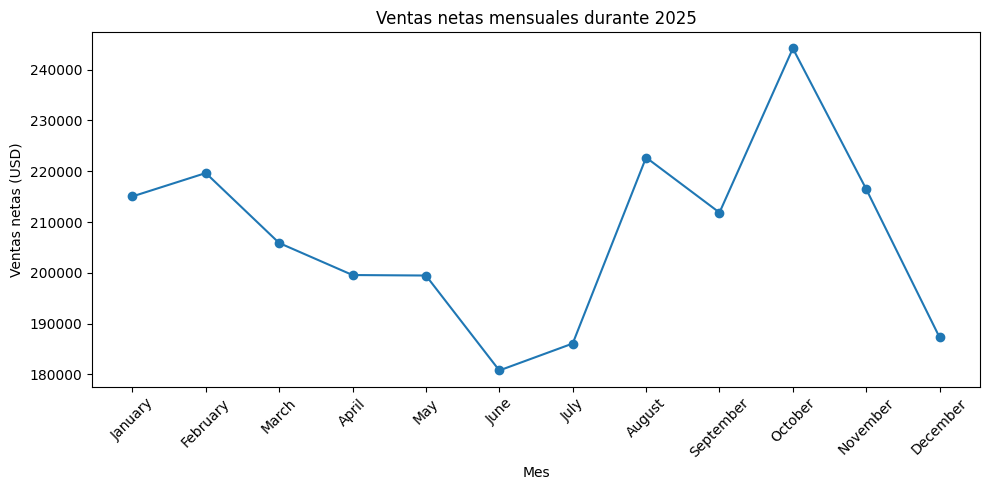

In [ ]:
ventas_mensuales = (
    df_limpio
    .groupby(["Mes_Num", "Mes"], as_index=False)["Ventas_Netas_USD"]
    .sum()
    .sort_values("Mes_Num")
)

plt.figure(figsize=(10, 5))

plt.plot(
    ventas_mensuales["Mes"],
    ventas_mensuales["Ventas_Netas_USD"],
    marker="o"
)

plt.title("Ventas netas mensuales durante 2025")
plt.xlabel("Mes")
plt.ylabel("Ventas netas (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8.2. Rentabilidad según el tipo de institución

Después de analizar el comportamiento general de las ventas durante 2025, se analiza
la rentabilidad según el tipo de institución.

Para realizar esta comparación se utiliza el `Margen_Bruto_Pct`, ya que permite
evaluar la rentabilidad de manera relativa al nivel de ventas y no únicamente por
el volumen de ingresos.

Se calcula el margen bruto promedio para cada tipo de institución con el objetivo
de identificar posibles diferencias de rentabilidad entre las categorías.

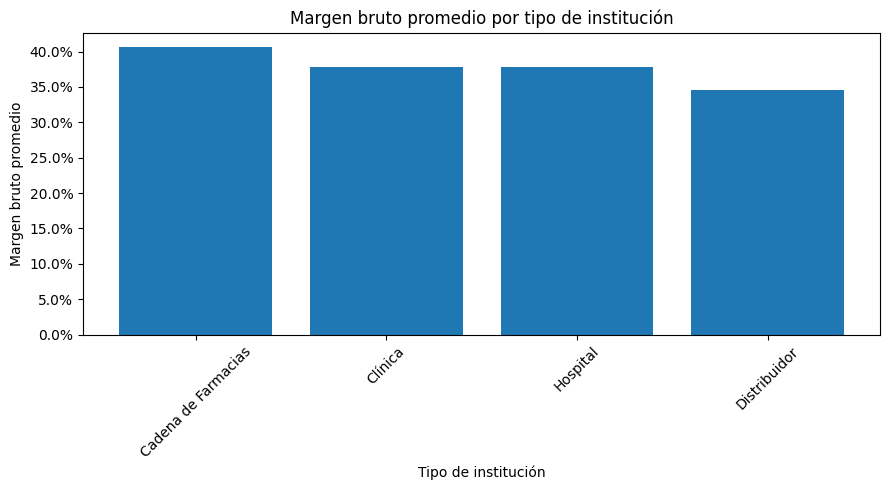

In [ ]:
import matplotlib.ticker as mtick
margen_institucion = (
    df_limpio
    .groupby("Tipo_Institución")["Margen_Bruto_Pct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.bar(
    margen_institucion.index,
    margen_institucion.values
)

plt.title("Margen bruto promedio por tipo de institución")
plt.xlabel("Tipo de institución")
plt.ylabel("Margen bruto promedio")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8.3. Riesgo de desabastecimiento según ubicación geográfica

Para analizar la dimensión de abastecimiento del proyecto, se compara el riesgo
promedio de desabastecimiento entre las diferentes regiones geográficas.

Se utiliza la variable `Riesgo_Stockout` como indicador del riesgo de
desabastecimiento y `Región` como variable de ubicación.

El objetivo es identificar si existen diferencias en el nivel de riesgo entre
las regiones y detectar posibles zonas que requieran mayor atención en las
decisiones de inventario y abastecimiento.

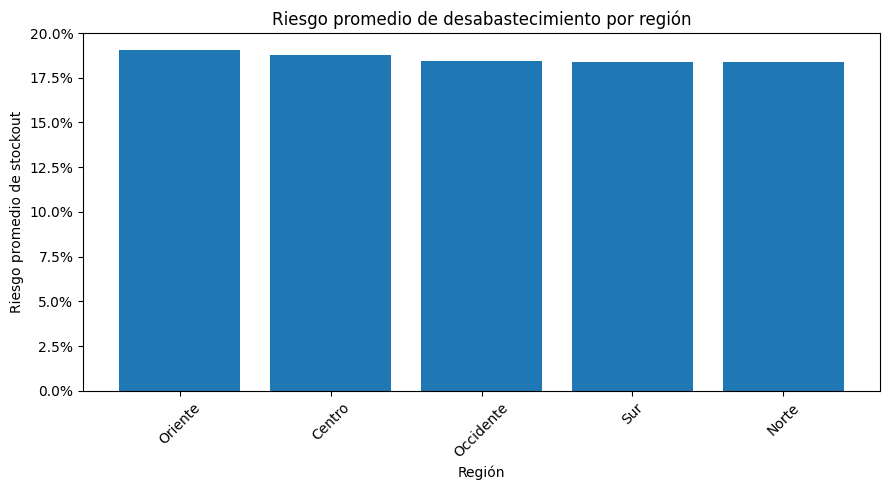

In [ ]:
import matplotlib.ticker as mtick

riesgo_region = (
    df_limpio[
        df_limpio["Riesgo_Stockout"].between(0, 1)
    ]
    .groupby("Región")["Riesgo_Stockout"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.bar(
    riesgo_region.index,
    riesgo_region.values
)

plt.title("Riesgo promedio de desabastecimiento por región")

plt.xlabel("Región")

plt.ylabel("Riesgo promedio de stockout")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## 8.4. Relación entre inventario y riesgo de desabastecimiento

Se analiza la relación entre los días de inventario disponibles y el riesgo de
desabastecimiento.

`Riesgo_Stockout` se interpreta como un porcentaje almacenado en escala decimal,
por lo que los valores entre 0 y 1 representan riesgos entre 0% y 100%.

Durante la exploración se identificaron 15 registros con valores superiores a 1,
equivalentes a riesgos superiores al 100%. Estos registros se consideran
anómalos para la interpretación porcentual y se mantienen identificados, sin
modificarlos ni eliminarlos del dataset.

In [ ]:
df_riesgo_valido = df_limpio[
    df_limpio["Riesgo_Stockout"].between(0, 1)
].copy()

print("Registros totales:", len(df_limpio))
print("Registros utilizados en el análisis:", len(df_riesgo_valido))
print(
    "Registros excluidos por riesgo > 100%:",
    len(df_limpio) - len(df_riesgo_valido)
)

Registros totales: 5025
Registros utilizados en el análisis: 5010
Registros excluidos por riesgo > 100%: 15


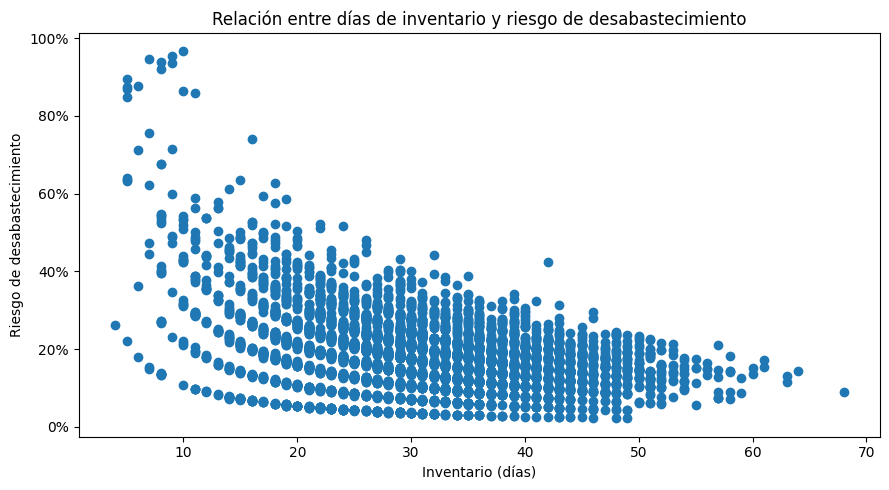

In [ ]:
plt.figure(figsize=(9, 5))

plt.scatter(
    df_riesgo_valido["Inventario_Días"],
    df_riesgo_valido["Riesgo_Stockout"]
)

plt.title("Relación entre días de inventario y riesgo de desabastecimiento")
plt.xlabel("Inventario (días)")
plt.ylabel("Riesgo de desabastecimiento")

plt.gca().yaxis.set_major_formatter(
    mtick.PercentFormatter(1)
)

plt.tight_layout()
plt.show()

## 8.5. Correlación entre inventario y riesgo de desabastecimiento

El análisis anterior mostró visualmente una posible relación inversa entre los días
de inventario y el riesgo de desabastecimiento.

Para complementar esta observación, se calcula la correlación de Pearson entre
`Inventario_Días` y `Riesgo_Stockout`, utilizando únicamente los registros cuyo
riesgo se encuentra dentro del rango válido de 0 a 1.

La correlación permite identificar la dirección y la intensidad de la relación
lineal entre ambas variables.

In [ ]:
correlacion = df_riesgo_valido[
    ["Inventario_Días", "Riesgo_Stockout"]
].corr().loc["Inventario_Días", "Riesgo_Stockout"]

print("CORRELACIÓN ENTRE INVENTARIO Y RIESGO")
print("=" * 50)
print(f"Correlación de Pearson: {correlacion:.4f}")

CORRELACIÓN ENTRE INVENTARIO Y RIESGO
Correlación de Pearson: -0.4098


## 8.6. Rentabilidad según el fabricante

Para completar el análisis de la rentabilidad, se estudia el comportamiento del
margen bruto según el fabricante.

Se utiliza `Fabricante` como variable de comparación y `Margen_Bruto_Pct` como
indicador de rentabilidad.

Antes de interpretar las diferencias entre fabricantes, se revisará también la
cantidad de registros disponibles para cada uno, con el fin de evitar conclusiones
basadas en grupos con una representación demasiado pequeña.

In [ ]:
#Verificamos cuantos fabricantes hay para observar si es necesario que hagamos la grafica con solo
#los fabricantes que más impacto tienen
fabricantes_resumen = (
    df_limpio
    .groupby("Fabricante")
    .agg(
        Registros=("Fabricante", "size"),
        Margen_Promedio=("Margen_Bruto_Pct", "mean")
    )
    .sort_values("Registros", ascending=False)
)

display(fabricantes_resumen)

,Registros,Margen_Promedio
Fabricante,,
Procaps,1604,0.330735
Genfar,1024,0.380216
Vitalis,864,0.481097
Sanofi,620,0.414596
Laboratorios MK,488,0.299782
Tecnoquímicas,415,0.408852


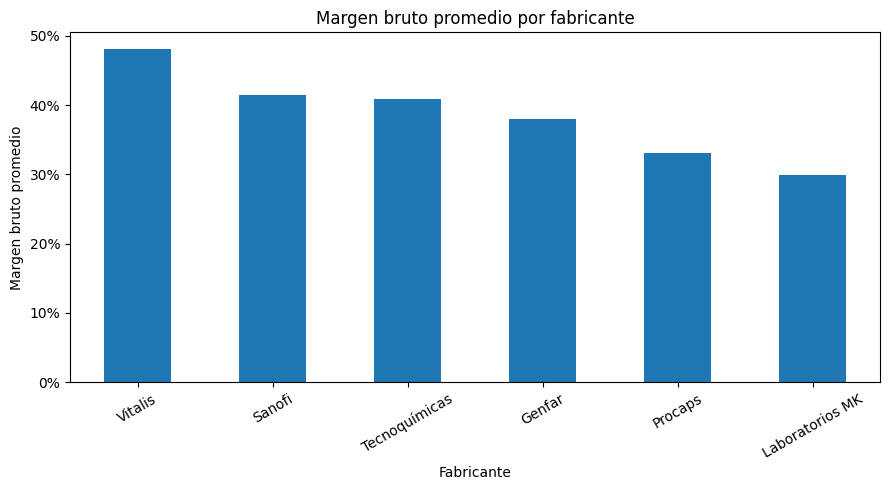

In [ ]:
import matplotlib.ticker as mtick

margen_fabricante = (
    df_limpio
    .groupby("Fabricante")["Margen_Bruto_Pct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

margen_fabricante.plot(kind="bar")

plt.title("Margen bruto promedio por fabricante")
plt.xlabel("Fabricante")
plt.ylabel("Margen bruto promedio")

plt.gca().yaxis.set_major_formatter(
    mtick.PercentFormatter(1)
)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 8.7. Ventas y rentabilidad según ubicación geográfica

Para complementar el análisis de la ubicación geográfica, se comparan las ventas netas y el margen bruto promedio entre las diferentes regiones.

Este análisis permite identificar si existen diferencias en el desempeño comercial y en la rentabilidad según la ubicación, aportando información para analizar cómo la dimensión geográfica se relaciona con la pregunta principal del proyecto.

Se utilizarán las variables `Ventas_Netas_USD` y `Margen_Bruto_Pct`, agrupadas por `Región`.


In [ ]:
# Resumen de ventas y rentabilidad por región

resumen_region = (
    df_limpio
    .groupby("Región")
    .agg(
        Ventas_Netas_USD=("Ventas_Netas_USD", "sum"),
        Utilidad_Bruta_USD=("Utilidad_Bruta_USD", "sum"),
        Margen_Bruto_Promedio=("Margen_Bruto_Pct", "mean")
    )
    .sort_values("Ventas_Netas_USD", ascending=False)
)

display(resumen_region)

,Ventas_Netas_USD,Utilidad_Bruta_USD,Margen_Bruto_Promedio
Región,,,
Centro,798883.147032,269687.147027,0.396203
Occidente,589909.852174,173836.302169,0.371239
Sur,430101.470086,137457.890086,0.383946
Norte,396980.456817,122084.246817,0.371401
Oriente,266822.206289,80943.906289,0.370862


Grafica:

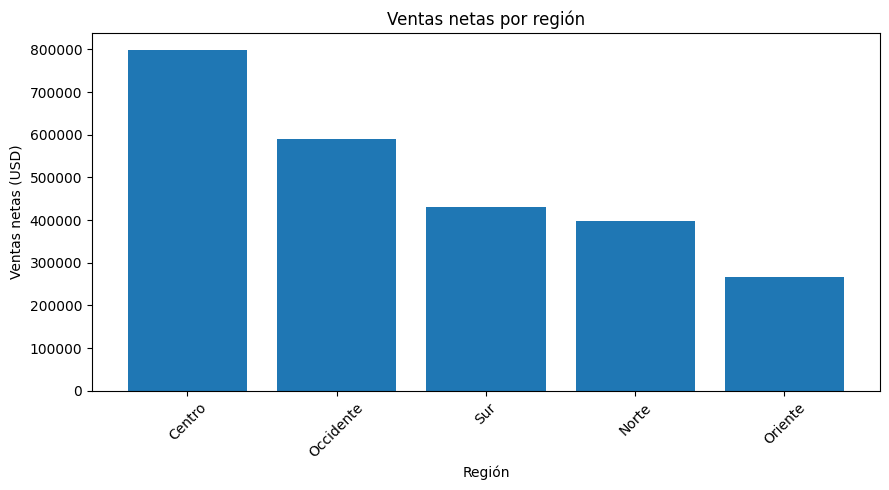

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    resumen_region.index,
    resumen_region["Ventas_Netas_USD"]
)

plt.title("Ventas netas por región")
plt.xlabel("Región")
plt.ylabel("Ventas netas (USD)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

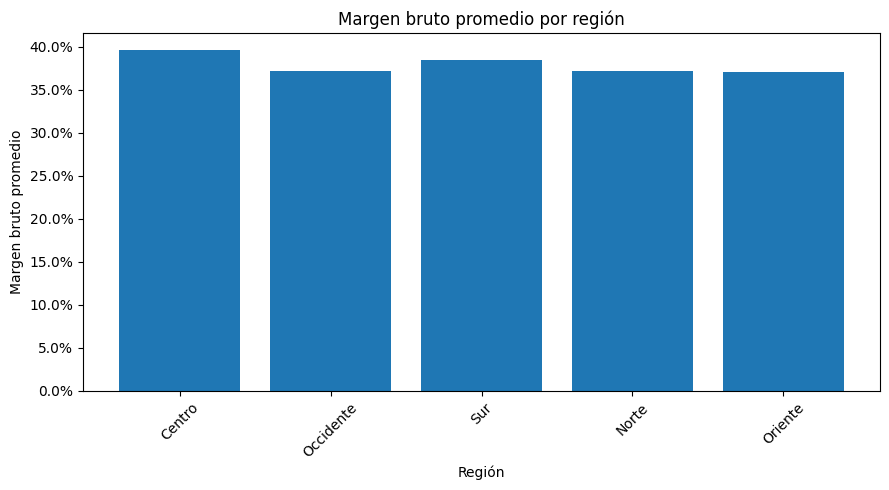

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    resumen_region.index,
    resumen_region["Margen_Bruto_Promedio"]
)

plt.title("Margen bruto promedio por región")
plt.xlabel("Región")
plt.ylabel("Margen bruto promedio")

plt.gca().yaxis.set_major_formatter(
    mtick.PercentFormatter(1)
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8.8. Relación entre Tiempo de entrega y riesgo de desabastecimiento

Además de los días de inventario, el tiempo de entrega puede estar relacionado con el riesgo de desabastecimiento.

Para explorar esta relación se compara `Lead_Time_Días` con `Riesgo_Stockout`, utilizando los registros cuyo riesgo se encuentra dentro del rango válido de 0 a 1.

El objetivo es identificar si existe algún patrón entre el tiempo requerido para recibir un producto y el nivel de riesgo de desabastecimiento.


In [ ]:
# Seleccionamos únicamente registros con riesgo válido entre 0 y 1

df_leadtime_riesgo = df_limpio[
    df_limpio["Riesgo_Stockout"].between(0, 1)
].copy()

print("Registros utilizados:", len(df_leadtime_riesgo))

Registros utilizados: 5010


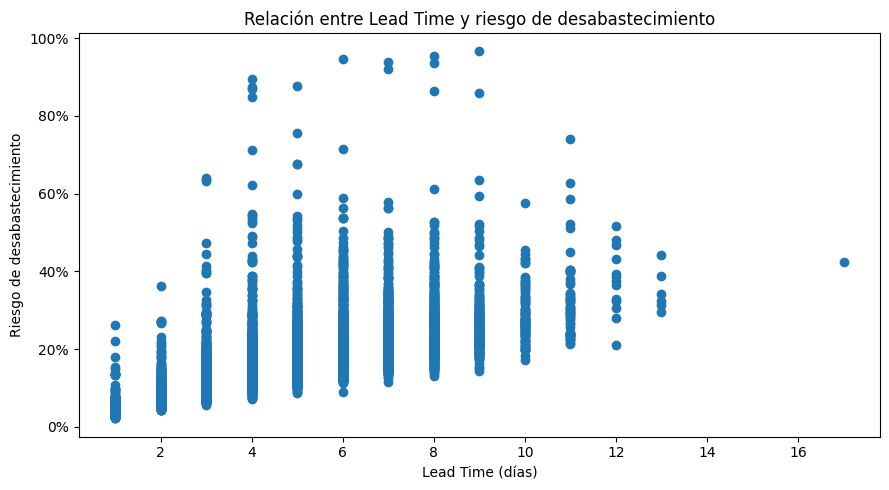

In [ ]:
plt.figure(figsize=(9, 5))

plt.scatter(
    df_leadtime_riesgo["Lead_Time_Días"],
    df_leadtime_riesgo["Riesgo_Stockout"]
)

plt.title("Relación entre Lead Time y riesgo de desabastecimiento")
plt.xlabel("Lead Time (días)")
plt.ylabel("Riesgo de desabastecimiento")

plt.gca().yaxis.set_major_formatter(
    mtick.PercentFormatter(1)
)

plt.tight_layout()
plt.show()

Correlación

In [ ]:
correlacion_leadtime = (
    df_leadtime_riesgo[
        ["Lead_Time_Días", "Riesgo_Stockout"]
    ]
    .corr()
    .loc["Lead_Time_Días", "Riesgo_Stockout"]
)

print("CORRELACIÓN ENTRE LEAD TIME Y RIESGO")
print("=" * 50)
print(f"Correlación de Pearson: {correlacion_leadtime:.4f}")

CORRELACIÓN ENTRE LEAD TIME Y RIESGO
Correlación de Pearson: 0.6024


## 8.9. Productos con alta rentabilidad y alto riesgo de desabastecimiento

Finalmente, se busca identificar productos que combinen niveles relativamente altos de rentabilidad y riesgo de desabastecimiento.

Para evitar establecer umbrales arbitrarios, primero se calculan los valores de referencia de ambas variables y posteriormente se identifican los productos que se encuentran en niveles altos de rentabilidad y riesgo.

Este análisis busca detectar productos que puedan requerir atención simultánea desde las perspectivas comercial y de abastecimiento.


Resumen de productos

In [ ]:
resumen_productos = (
    df_limpio
    .groupby("Producto")
    .agg(
        Ventas_Netas_USD=("Ventas_Netas_USD", "sum"),
        Utilidad_Bruta_USD=("Utilidad_Bruta_USD", "sum"),
        Margen_Bruto_Promedio=("Margen_Bruto_Pct", "mean"),
        Riesgo_Stockout_Promedio=("Riesgo_Stockout", "mean"),
        Registros=("Producto", "size")
    )
)

# Mostramos primero el resumen completo ordenado por rentabilidad
resumen_productos = resumen_productos.sort_values(
    "Margen_Bruto_Promedio",
    ascending=False
)

display(resumen_productos)

,Ventas_Netas_USD,Utilidad_Bruta_USD,Margen_Bruto_Promedio,Riesgo_Stockout_Promedio,Registros
Producto,,,,,
Ibuprofeno 400mg,72170.426622,35413.816622,0.495178,0.179373,331
Acetaminofén 500mg,68781.730277,33101.220277,0.481977,0.173419,324
Azitromicina 500mg,75143.274456,34538.424456,0.46209,0.162562,219
Metformina 850mg,53967.35363,24286.69363,0.457553,0.175143,210
Omeprazol 20mg,76632.293457,34711.523457,0.454991,0.177667,301
Montelukast 10mg,101366.800114,45196.460114,0.44734,0.207143,260
Amoxicilina 500mg,46850.642552,20229.972552,0.433533,0.165395,170
Losartán 50mg,65607.165555,27490.375555,0.422278,0.162587,217
Salbutamol Inhalador,134394.280618,54677.170618,0.406788,0.187822,278


Valores de referencia

In [ ]:
# Utilizamos únicamente riesgos válidos para calcular el punto de referencia

productos_validos = resumen_productos[
    resumen_productos["Riesgo_Stockout_Promedio"].between(0, 1)
].copy()

umbral_margen = productos_validos["Margen_Bruto_Promedio"].median()
umbral_riesgo = productos_validos["Riesgo_Stockout_Promedio"].median()

print(f"Margen bruto mediano: {umbral_margen:.2%}")
print(f"Riesgo de stockout mediano: {umbral_riesgo:.2%}")

Margen bruto mediano: 39.37%
Riesgo de stockout mediano: 17.71%


Identificación de productos prioritarios

In [ ]:
productos_prioritarios = productos_validos[
    (productos_validos["Margen_Bruto_Promedio"] >= umbral_margen) &
    (productos_validos["Riesgo_Stockout_Promedio"] >= umbral_riesgo)
].sort_values(
    ["Margen_Bruto_Promedio", "Riesgo_Stockout_Promedio"],
    ascending=False
)

display(productos_prioritarios)

,Ventas_Netas_USD,Utilidad_Bruta_USD,Margen_Bruto_Promedio,Riesgo_Stockout_Promedio,Registros
Producto,,,,,
Ibuprofeno 400mg,72170.426622,35413.816622,0.495178,0.179373,331
Omeprazol 20mg,76632.293457,34711.523457,0.454991,0.177667,301
Montelukast 10mg,101366.800114,45196.460114,0.44734,0.207143,260
Salbutamol Inhalador,134394.280618,54677.170618,0.406788,0.187822,278
Budesonida Nebulizable,141512.151224,55496.711224,0.394688,0.200895,302
Lactulosa Jarabe,67902.485731,26524.705731,0.393653,0.181547,233


### Productos con mayor riesgo de desabastecimiento

Para facilitar la interpretación, se seleccionan los productos con los mayores niveles promedio de riesgo de desabastecimiento y se compara su comportamiento con el margen bruto promedio.

Esta visualización permite identificar productos que podrían requerir mayor atención desde la perspectiva de abastecimiento y, al mismo tiempo, observar su nivel de rentabilidad.

In [ ]:
# Seleccionar los 10 productos con mayor riesgo promedio

top_riesgo_productos = (
    productos_validos
    .sort_values("Riesgo_Stockout_Promedio", ascending=False)
    .head(10)
    .sort_values("Riesgo_Stockout_Promedio", ascending=True)
)

display(
    top_riesgo_productos[
        [
            "Margen_Bruto_Promedio",
            "Riesgo_Stockout_Promedio",
            "Ventas_Netas_USD",
            "Utilidad_Bruta_USD"
        ]
    ]
)

,Margen_Bruto_Promedio,Riesgo_Stockout_Promedio,Ventas_Netas_USD,Utilidad_Bruta_USD
Producto,,,,
Ibuprofeno 400mg,0.495178,0.179373,72170.426622,35413.816622
Lactulosa Jarabe,0.393653,0.181547,67902.485731,26524.705731
Salbutamol Inhalador,0.406788,0.187822,134394.280618,54677.170618
Budesonida Nebulizable,0.394688,0.200895,141512.151224,55496.711224
Montelukast 10mg,0.44734,0.207143,101366.800114,45196.460114
Paclitaxel,0.224674,0.245384,104512.921992,21104.741992
Vacuna VPH,0.264348,0.252676,165705.894075,41611.154075
Trastuzumab,0.159123,0.257368,223632.622315,31989.04231
Vacuna Influenza,0.341152,0.260785,82368.353177,27621.463177


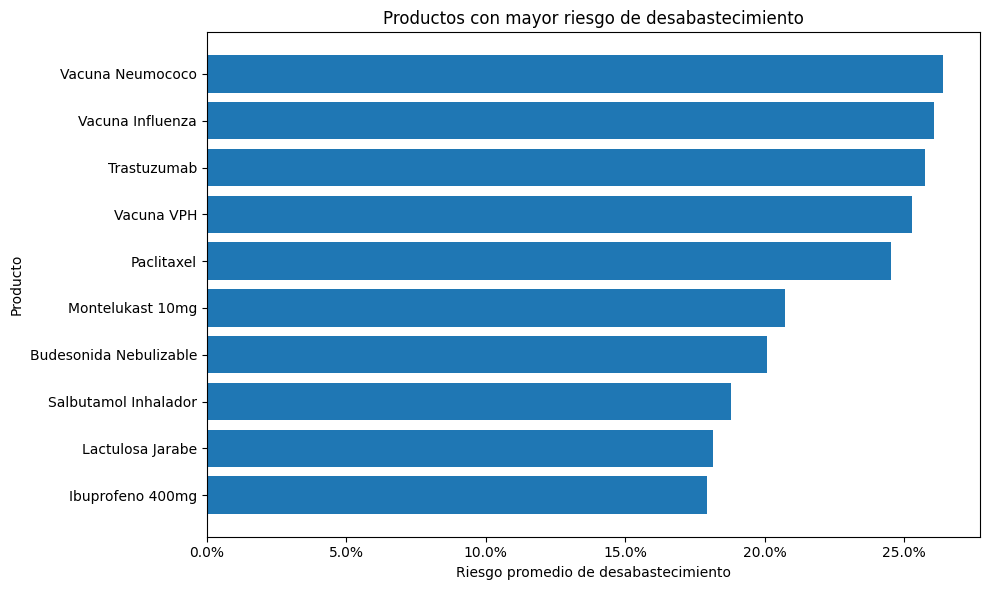

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_riesgo_productos.index,
    top_riesgo_productos["Riesgo_Stockout_Promedio"]
)

plt.title("Productos con mayor riesgo de desabastecimiento")
plt.xlabel("Riesgo promedio de desabastecimiento")
plt.ylabel("Producto")

plt.gca().xaxis.set_major_formatter(
    mtick.PercentFormatter(1)
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# RESUMEN DE RESULTADOS PARA EL PUNTO 9
# ============================================================

print("=" * 70)
print("RESUMEN DE RESULTADOS DEL EDA")
print("=" * 70)

# 1. Ventas mensuales
ventas_mensuales = (
    df_limpio
    .groupby("Mes_Num")["Ventas_Netas_USD"]
    .sum()
    .sort_values(ascending=False)
)

print("\n1. VENTAS MENSUALES")
print("-" * 70)
print(f"Mes con mayores ventas: {ventas_mensuales.index[0]}")
print(f"Ventas: ${ventas_mensuales.iloc[0]:,.2f}")
print(f"Mes con menores ventas: {ventas_mensuales.index[-1]}")
print(f"Ventas: ${ventas_mensuales.iloc[-1]:,.2f}")


# 2. Rentabilidad por tipo de institución
institucion_margen = (
    df_limpio
    .groupby("Tipo_Institución")["Margen_Bruto_Pct"]
    .mean()
    .sort_values(ascending=False)
)

print("\n2. RENTABILIDAD POR TIPO DE INSTITUCIÓN")
print("-" * 70)
print(f"Mayor margen promedio: {institucion_margen.index[0]}")
print(f"Margen: {institucion_margen.iloc[0]:.2%}")
print(f"Menor margen promedio: {institucion_margen.index[-1]}")
print(f"Margen: {institucion_margen.iloc[-1]:.2%}")


# 3. Riesgo por región
region_riesgo = (
    df_limpio[
        df_limpio["Riesgo_Stockout"].between(0, 1)
    ]
    .groupby("Región")["Riesgo_Stockout"]
    .mean()
    .sort_values(ascending=False)
)

print("\n3. RIESGO DE DESABASTECIMIENTO POR REGIÓN")
print("-" * 70)
print(f"Mayor riesgo promedio: {region_riesgo.index[0]}")
print(f"Riesgo: {region_riesgo.iloc[0]:.2%}")
print(f"Menor riesgo promedio: {region_riesgo.index[-1]}")
print(f"Riesgo: {region_riesgo.iloc[-1]:.2%}")


# 4. Rentabilidad por fabricante
fabricante_margen = (
    df_limpio
    .groupby("Fabricante")["Margen_Bruto_Pct"]
    .mean()
    .sort_values(ascending=False)
)

print("\n4. RENTABILIDAD POR FABRICANTE")
print("-" * 70)
print(f"Mayor margen promedio: {fabricante_margen.index[0]}")
print(f"Margen: {fabricante_margen.iloc[0]:.2%}")
print(f"Menor margen promedio: {fabricante_margen.index[-1]}")
print(f"Margen: {fabricante_margen.iloc[-1]:.2%}")


# 5. Lead Time vs. riesgo
print("\n5. LEAD TIME Y RIESGO")
print("-" * 70)
print(f"Correlación Lead Time - Riesgo: {correlacion_leadtime:.4f}")


# 6. Inventario vs. riesgo
df_inventario_riesgo = df_limpio[
    df_limpio["Riesgo_Stockout"].between(0, 1)
][["Inventario_Días", "Riesgo_Stockout"]].dropna()

correlacion_inventario = (
    df_inventario_riesgo
    .corr()
    .loc["Inventario_Días", "Riesgo_Stockout"]
)

print("\n6. INVENTARIO Y RIESGO")
print("-" * 70)
print(f"Correlación Inventario - Riesgo: {correlacion_inventario:.4f}")


# 7. Productos con mayor riesgo
print("\n7. PRODUCTOS CON MAYOR RIESGO")
print("-" * 70)

display(
    top_riesgo_productos[
        [
            "Margen_Bruto_Promedio",
            "Riesgo_Stockout_Promedio",
            "Ventas_Netas_USD",
            "Utilidad_Bruta_USD"
        ]
    ]
)

RESUMEN DE RESULTADOS DEL EDA

1. VENTAS MENSUALES
----------------------------------------------------------------------
Mes con mayores ventas: 10
Ventas: $244,180.77
Mes con menores ventas: 6
Ventas: $180,789.14

2. RENTABILIDAD POR TIPO DE INSTITUCIÓN
----------------------------------------------------------------------
Mayor margen promedio: Cadena de Farmacias
Margen: 40.61%
Menor margen promedio: Distribuidor
Margen: 34.60%

3. RIESGO DE DESABASTECIMIENTO POR REGIÓN
----------------------------------------------------------------------
Mayor riesgo promedio: Oriente
Riesgo: 19.06%
Menor riesgo promedio: Norte
Riesgo: 18.35%

4. RENTABILIDAD POR FABRICANTE
----------------------------------------------------------------------
Mayor margen promedio: Vitalis
Margen: 48.11%
Menor margen promedio: Laboratorios MK
Margen: 29.98%

5. LEAD TIME Y RIESGO
----------------------------------------------------------------------
Correlación Lead Time - Riesgo: 0.6024

6. INVENTARIO Y RIESGO


,Margen_Bruto_Promedio,Riesgo_Stockout_Promedio,Ventas_Netas_USD,Utilidad_Bruta_USD
Producto,,,,
Ibuprofeno 400mg,0.495178,0.179373,72170.426622,35413.816622
Lactulosa Jarabe,0.393653,0.181547,67902.485731,26524.705731
Salbutamol Inhalador,0.406788,0.187822,134394.280618,54677.170618
Budesonida Nebulizable,0.394688,0.200895,141512.151224,55496.711224
Montelukast 10mg,0.44734,0.207143,101366.800114,45196.460114
Paclitaxel,0.224674,0.245384,104512.921992,21104.741992
Vacuna VPH,0.264348,0.252676,165705.894075,41611.154075
Trastuzumab,0.159123,0.257368,223632.622315,31989.04231
Vacuna Influenza,0.341152,0.260785,82368.353177,27621.463177


In [ ]:
# ============================================================
# RESULTADOS COMPLEMENTARIOS PARA EL PUNTO 9
# ============================================================

print("=" * 70)
print("RESULTADOS COMPLEMENTARIOS DEL EDA")
print("=" * 70)


# 1. VENTAS Y RENTABILIDAD POR TIPO DE INSTITUCIÓN
institucion_resumen = (
    df_limpio
    .groupby("Tipo_Institución")
    .agg(
        Ventas_Netas_USD=("Ventas_Netas_USD", "sum"),
        Utilidad_Bruta_USD=("Utilidad_Bruta_USD", "sum"),
        Margen_Bruto_Promedio=("Margen_Bruto_Pct", "mean")
    )
    .sort_values("Ventas_Netas_USD", ascending=False)
)

print("\n1. VENTAS Y RENTABILIDAD POR TIPO DE INSTITUCIÓN")
print("-" * 70)

display(institucion_resumen)


# 2. VENTAS Y RENTABILIDAD POR FABRICANTE
fabricante_resumen = (
    df_limpio
    .groupby("Fabricante")
    .agg(
        Ventas_Netas_USD=("Ventas_Netas_USD", "sum"),
        Utilidad_Bruta_USD=("Utilidad_Bruta_USD", "sum"),
        Margen_Bruto_Promedio=("Margen_Bruto_Pct", "mean")
    )
    .sort_values("Ventas_Netas_USD", ascending=False)
)

print("\n2. VENTAS Y RENTABILIDAD POR FABRICANTE")
print("-" * 70)

display(fabricante_resumen)


# 3. VENTAS, RENTABILIDAD Y RIESGO POR REGIÓN
region_resumen = (
    df_limpio[
        df_limpio["Riesgo_Stockout"].between(0, 1)
    ]
    .groupby("Región")
    .agg(
        Ventas_Netas_USD=("Ventas_Netas_USD", "sum"),
        Utilidad_Bruta_USD=("Utilidad_Bruta_USD", "sum"),
        Margen_Bruto_Promedio=("Margen_Bruto_Pct", "mean"),
        Riesgo_Stockout_Promedio=("Riesgo_Stockout", "mean")
    )
    .sort_values("Ventas_Netas_USD", ascending=False)
)

print("\n3. VENTAS, RENTABILIDAD Y RIESGO POR REGIÓN")
print("-" * 70)

display(region_resumen)


# 4. CIUDADES CON MAYORES VENTAS
ciudad_ventas = (
    df_limpio
    .groupby("Ciudad")
    .agg(
        Ventas_Netas_USD=("Ventas_Netas_USD", "sum"),
        Margen_Bruto_Promedio=("Margen_Bruto_Pct", "mean")
    )
    .sort_values("Ventas_Netas_USD", ascending=False)
    .head(10)
)

print("\n4. TOP 10 CIUDADES POR VENTAS")
print("-" * 70)

display(ciudad_ventas)

RESULTADOS COMPLEMENTARIOS DEL EDA

1. VENTAS Y RENTABILIDAD POR TIPO DE INSTITUCIÓN
----------------------------------------------------------------------


,Ventas_Netas_USD,Utilidad_Bruta_USD,Margen_Bruto_Promedio
Tipo_Institución,,,
Distribuidor,981469.631495,269245.331485,0.346019
Hospital,603254.183407,204475.453407,0.378372
Cadena de Farmacias,474093.545075,170726.535075,0.406077
Clínica,430200.589133,141916.739133,0.378517



2. VENTAS Y RENTABILIDAD POR FABRICANTE
----------------------------------------------------------------------


,Ventas_Netas_USD,Utilidad_Bruta_USD,Margen_Bruto_Promedio
Fabricante,,,
Procaps,1156661.033161,287258.803151,0.330735
Genfar,433437.169816,164956.849816,0.380216
Laboratorios MK,365556.217135,104013.247135,0.299782
Vitalis,194662.383745,92677.563745,0.481097
Sanofi,180439.795941,74279.665941,0.414596
Tecnoquímicas,155276.825347,62025.295347,0.408852



3. VENTAS, RENTABILIDAD Y RIESGO POR REGIÓN
----------------------------------------------------------------------


,Ventas_Netas_USD,Utilidad_Bruta_USD,Margen_Bruto_Promedio,Riesgo_Stockout_Promedio
Región,,,,
Centro,797128.87247,268934.942465,0.396101,0.187887
Occidente,589521.082974,173665.782969,0.371176,0.184365
Sur,428917.568829,136891.128829,0.383545,0.183918
Norte,396033.441043,121756.501043,0.371439,0.183533
Oriente,266032.748325,80641.388325,0.370824,0.190582



4. TOP 10 CIUDADES POR VENTAS
----------------------------------------------------------------------


,Ventas_Netas_USD,Margen_Bruto_Promedio
Ciudad,,
Bogotá,282075.317939,0.396457
Soacha,265195.893474,0.395138
Tunja,254118.877913,0.3972
Medellín,223636.553871,0.373732
Bello,189607.019342,0.366943
Pereira,176906.930075,0.373677
Cali,148497.562588,0.393967
Cartagena,145009.497232,0.372825
Pasto,143279.502744,0.376676


# 9. Patrones y posibles respuestas

A partir de los resultados obtenidos en el análisis exploratorio, se identifican patrones relacionados con el comportamiento de las ventas, la rentabilidad, la ubicación geográfica y el riesgo de desabastecimiento.

Estos patrones permiten plantear posibles respuestas a la pregunta principal del proyecto y reconocer comportamientos que podrían ser relevantes para la toma de decisiones sobre ventas, inventario y abastecimiento.

Las relaciones identificadas se interpretan como asociaciones observadas en los datos y no como relaciones causales.

## 9.1. Comportamiento de las ventas

Las ventas netas presentan variaciones a lo largo de 2025. El mayor nivel mensual de ventas se observa en octubre, con aproximadamente USD 244.181, mientras que el menor corresponde a junio, con aproximadamente USD 180.789.

Esto evidencia que el comportamiento comercial no fue uniforme durante el año. La diferencia entre ambos meses representa una variación relevante en el nivel de ventas, por lo que el comportamiento temporal puede ser considerado al analizar decisiones comerciales y de abastecimiento.

In [ ]:
# Resumen del comportamiento mensual de las ventas

print("COMPORTAMIENTO DE LAS VENTAS EN 2025")
print("=" * 60)

mes_mayor = ventas_mensuales.idxmax()
mes_menor = ventas_mensuales.idxmin()

venta_mayor = ventas_mensuales.max()
venta_menor = ventas_mensuales.min()

print(f"Mes con mayores ventas: {mes_mayor}")
print(f"Ventas: ${venta_mayor:,.2f}")

print(f"\nMes con menores ventas: {mes_menor}")
print(f"Ventas: ${venta_menor:,.2f}")

variacion = venta_mayor - venta_menor
porcentaje_variacion = variacion / venta_menor

print(f"\nDiferencia entre ambos meses: ${variacion:,.2f}")
print(f"Variación relativa: {porcentaje_variacion:.2%}")

COMPORTAMIENTO DE LAS VENTAS EN 2025
Mes con mayores ventas: 10
Ventas: $244,180.77

Mes con menores ventas: 6
Ventas: $180,789.14

Diferencia entre ambos meses: $63,391.64
Variación relativa: 35.06%


## 9.2. Rentabilidad según tipo de institución y fabricante

Se identifican diferencias en el margen bruto promedio tanto entre tipos de institución como entre fabricantes.

Por tipo de institución, las Cadenas de Farmacias presentan el mayor margen bruto promedio, con 40,61%, mientras que los Distribuidores presentan el menor, con 34,60%.

Por fabricante, Vitalis presenta el mayor margen bruto promedio, con 48,11%, mientras que Laboratorios MK presenta el menor, con 29,98%.

Estos resultados sugieren que la rentabilidad no es homogénea entre las diferentes instituciones y fabricantes. Sin embargo, las diferencias observadas deben interpretarse como patrones del conjunto de datos analizado y no como evidencia de causalidad.

In [ ]:
# Comparación de rentabilidad por institución y fabricante

print("RENTABILIDAD POR TIPO DE INSTITUCIÓN")
print("=" * 60)

display(
    institucion_resumen[
        [
            "Ventas_Netas_USD",
            "Utilidad_Bruta_USD",
            "Margen_Bruto_Promedio"
        ]
    ].sort_values(
        "Margen_Bruto_Promedio",
        ascending=False
    )
)


print("\nRENTABILIDAD POR FABRICANTE")
print("=" * 60)

display(
    fabricante_resumen[
        [
            "Ventas_Netas_USD",
            "Utilidad_Bruta_USD",
            "Margen_Bruto_Promedio"
        ]
    ].sort_values(
        "Margen_Bruto_Promedio",
        ascending=False
    )
)

RENTABILIDAD POR TIPO DE INSTITUCIÓN


,Ventas_Netas_USD,Utilidad_Bruta_USD,Margen_Bruto_Promedio
Tipo_Institución,,,
Cadena de Farmacias,474093.545075,170726.535075,0.406077
Clínica,430200.589133,141916.739133,0.378517
Hospital,603254.183407,204475.453407,0.378372
Distribuidor,981469.631495,269245.331485,0.346019



RENTABILIDAD POR FABRICANTE


,Ventas_Netas_USD,Utilidad_Bruta_USD,Margen_Bruto_Promedio
Fabricante,,,
Vitalis,194662.383745,92677.563745,0.481097
Sanofi,180439.795941,74279.665941,0.414596
Tecnoquímicas,155276.825347,62025.295347,0.408852
Genfar,433437.169816,164956.849816,0.380216
Procaps,1156661.033161,287258.803151,0.330735
Laboratorios MK,365556.217135,104013.247135,0.299782


## 9.3. Comportamiento geográfico

El comportamiento geográfico presenta diferencias tanto en el volumen de ventas como en el margen y el riesgo de desabastecimiento.

La región Centro registra el mayor nivel de ventas netas, con aproximadamente USD 797.129, y también presenta el mayor margen bruto promedio entre las regiones analizadas, con 39,61%.

En contraste, Oriente registra el menor nivel de ventas netas, con aproximadamente USD 266.033, y presenta el mayor riesgo promedio de desabastecimiento, con 19,06%.

La región Norte presenta el menor riesgo promedio, con 18,35%.

Estos resultados sugieren que el desempeño comercial y el riesgo de desabastecimiento presentan diferencias según la ubicación geográfica, lo que podría ser relevante para la planificación de ventas e inventario.

In [ ]:
# Comparación de ventas, rentabilidad y riesgo por región

display(
    region_resumen[
        [
            "Ventas_Netas_USD",
            "Utilidad_Bruta_USD",
            "Margen_Bruto_Promedio",
            "Riesgo_Stockout_Promedio"
        ]
    ]
)

,Ventas_Netas_USD,Utilidad_Bruta_USD,Margen_Bruto_Promedio,Riesgo_Stockout_Promedio
Región,,,,
Centro,797128.87247,268934.942465,0.396101,0.187887
Occidente,589521.082974,173665.782969,0.371176,0.184365
Sur,428917.568829,136891.128829,0.383545,0.183918
Norte,396033.441043,121756.501043,0.371439,0.183533
Oriente,266032.748325,80641.388325,0.370824,0.190582


## 9.4. Inventario, Lead Time y riesgo de desabastecimiento

El análisis de las variables de abastecimiento muestra dos relaciones relevantes.

La correlación entre Lead Time y riesgo de desabastecimiento es de 0,6024, lo que indica una asociación positiva de magnitud moderada. En los datos analizados, los mayores tiempos de entrega tienden a presentarse junto con mayores niveles de riesgo.

Por otra parte, la correlación entre los días de inventario y el riesgo de desabastecimiento es de -0,4098, lo que indica una asociación negativa de magnitud moderada. Esto sugiere que mayores niveles de inventario tienden a estar asociados con menores niveles de riesgo.

Estos resultados pueden ser relevantes para las decisiones de abastecimiento, aunque las correlaciones no permiten afirmar que una variable cause directamente cambios en la otra.

In [ ]:
# Resumen de las relaciones entre variables de abastecimiento

print("RELACIONES ENTRE ABASTECIMIENTO Y RIESGO")
print("=" * 60)

print(f"Correlación Lead Time - Riesgo: {correlacion_leadtime:.4f}")
print(f"Correlación Inventario - Riesgo: {correlacion_inventario:.4f}")

print("\nInterpretación:")
print("- Lead Time presenta una asociación positiva moderada con el riesgo.")
print("- Inventario presenta una asociación negativa moderada con el riesgo.")
print("- Estas asociaciones no implican causalidad.")

RELACIONES ENTRE ABASTECIMIENTO Y RIESGO
Correlación Lead Time - Riesgo: 0.6024
Correlación Inventario - Riesgo: -0.4098

Interpretación:
- Lead Time presenta una asociación positiva moderada con el riesgo.
- Inventario presenta una asociación negativa moderada con el riesgo.
- Estas asociaciones no implican causalidad.


## 9.5. Productos prioritarios

El análisis de los productos con mayores niveles promedio de riesgo permite identificar aquellos que podrían requerir mayor atención desde la perspectiva de abastecimiento.

Entre los productos con mayor riesgo se encuentran Vacuna Neumococo, Vacuna Influenza, Trastuzumab, Vacuna VPH y Paclitaxel.

El comportamiento de estos productos no es homogéneo desde el punto de vista de la rentabilidad. Por ejemplo, Ibuprofeno 400mg presenta un margen bruto promedio de 49,52% y un riesgo promedio de 17,94%, mientras que Trastuzumab presenta un riesgo promedio de 25,74% y un margen promedio de 15,91%.

Esto muestra que un mayor riesgo de desabastecimiento no necesariamente está acompañado de una mayor rentabilidad. Por ello, las decisiones de abastecimiento podrían considerar conjuntamente el nivel de riesgo y la importancia económica de cada producto.

In [ ]:
# Productos con mayor riesgo y sus principales indicadores económicos

productos_presentacion = (
    top_riesgo_productos[
        [
            "Riesgo_Stockout_Promedio",
            "Margen_Bruto_Promedio",
            "Ventas_Netas_USD",
            "Utilidad_Bruta_USD"
        ]
    ]
    .sort_values(
        "Riesgo_Stockout_Promedio",
        ascending=False
    )
)

display(productos_presentacion)

,Riesgo_Stockout_Promedio,Margen_Bruto_Promedio,Ventas_Netas_USD,Utilidad_Bruta_USD
Producto,,,,
Vacuna Neumococo,0.263974,0.295865,117481.969883,34780.629883
Vacuna Influenza,0.260785,0.341152,82368.353177,27621.463177
Trastuzumab,0.257368,0.159123,223632.622315,31989.04231
Vacuna VPH,0.252676,0.264348,165705.894075,41611.154075
Paclitaxel,0.245384,0.224674,104512.921992,21104.741992
Montelukast 10mg,0.207143,0.44734,101366.800114,45196.460114
Budesonida Nebulizable,0.200895,0.394688,141512.151224,55496.711224
Salbutamol Inhalador,0.187822,0.406788,134394.280618,54677.170618
Lactulosa Jarabe,0.181547,0.393653,67902.485731,26524.705731


## 9.6. Posible respuesta a la pregunta principal

A partir del análisis exploratorio, se observa que el tipo de institución, el fabricante y la ubicación geográfica presentan diferencias en los niveles de rentabilidad, ventas y riesgo de desabastecimiento.

En términos de rentabilidad, se identifican diferencias entre instituciones y fabricantes. Las Cadenas de Farmacias presentan el mayor margen promedio entre los tipos de institución, mientras que Vitalis presenta el mayor margen promedio entre los fabricantes analizados.

Desde la perspectiva geográfica, la región Centro concentra el mayor nivel de ventas y presenta el mayor margen promedio, mientras que Oriente registra el mayor riesgo promedio de desabastecimiento.

En cuanto al abastecimiento, se observa una asociación positiva moderada entre el Lead Time y el riesgo de desabastecimiento, mientras que los días de inventario presentan una asociación negativa moderada con dicho riesgo.

En conjunto, los resultados sugieren que las decisiones de ventas, inventario y abastecimiento pueden beneficiarse de un análisis diferenciado según institución, fabricante, ubicación y producto. Sin embargo, estos resultados representan asociaciones observadas en los datos y no permiten establecer relaciones causales.

## 9.7. Patrones que pueden apoyar la toma de decisiones

Los resultados del EDA permiten identificar algunos patrones que podrían ser considerados en la toma de decisiones:

- **Ventas:** las variaciones mensuales sugieren la importancia de monitorear el comportamiento comercial durante el año.
- **Rentabilidad:** las diferencias entre instituciones y fabricantes pueden apoyar una segmentación de las estrategias comerciales.
- **Ubicación:** las diferencias entre regiones permiten considerar el contexto geográfico al analizar ventas, rentabilidad y riesgo.
- **Inventario:** la asociación negativa observada entre inventario y riesgo puede ser relevante para evaluar niveles de disponibilidad.
- **Lead Time:** la asociación positiva observada con el riesgo sugiere que los tiempos de entrega deben considerarse dentro de la planificación del abastecimiento.
- **Productos:** los productos con mayor riesgo pueden priorizarse considerando simultáneamente su nivel de ventas, utilidad y margen.

Estas observaciones representan oportunidades de análisis y apoyo a la toma de decisiones, pero no deben interpretarse como reglas causales o recomendaciones definitivas sin análisis adicionales.

# 10. Crudo vs. limpio

La comparación entre los datos crudos y los datos limpios permite evidenciar la importancia de la preparación de los datos antes de realizar el análisis exploratorio.

Durante la limpieza se identificaron problemas relacionados con registros duplicados, formatos de fecha, inconsistencias en variables categóricas y formatos numéricos.

Estas inconsistencias podían afectar agrupaciones, cálculos y comparaciones. Por esta razón, se conservaron los datos originales y se trabajó sobre una copia para realizar las transformaciones necesarias.

## 10.1. Resumen de los principales cambios

Los principales procesos realizados durante la limpieza fueron:

- Eliminación de registros con `ID_Registro` duplicado.
- Normalización del formato de `Fecha`.
- Unificación de las diferentes formas de escritura de `Mes`.
- Normalización de ciudades y otras variables categóricas.
- Conversión de variables numéricas representadas inicialmente con diferentes formatos.
- Identificación y auditoría de valores faltantes.
- Validación de la consistencia entre fechas, meses y variables financieras.

Estos cambios permiten trabajar con una estructura de datos más consistente para el análisis exploratorio.

In [ ]:
# Resumen comparativo entre dataset crudo y dataset limpio

print("COMPARACIÓN GENERAL: DATOS CRUDOS VS. DATOS LIMPIOS")
print("=" * 65)

print(f"Registros en datos crudos:   {df.shape[0]}")
print(f"Registros en datos limpios:  {df_limpio.shape[0]}")
print(f"Registros eliminados:        {df.shape[0] - df_limpio.shape[0]}")

print("\nColumnas:")
print(f"Datos crudos:   {df.shape[1]}")
print(f"Datos limpios:  {df_limpio.shape[1]}")

print("\nID_Registro duplicados:")
print(f"Antes:   {df['ID_Registro'].duplicated().sum()}")
print(f"Después: {df_limpio['ID_Registro'].duplicated().sum()}")

print("\nValores faltantes:")
print(f"Antes:   {df.isna().sum().sum()}")
print(f"Después: {df_limpio.isna().sum().sum()}")

COMPARACIÓN GENERAL: DATOS CRUDOS VS. DATOS LIMPIOS
Registros en datos crudos:   5075
Registros en datos limpios:  5025
Registros eliminados:        50

Columnas:
Datos crudos:   33
Datos limpios:  33

ID_Registro duplicados:
Antes:   50
Después: 0

Valores faltantes:
Antes:   61
Después: 63


## 10.2. Registros duplicados

En los datos crudos se identificaron registros con `ID_Registro` repetido.

Debido a que este identificador representa cada operación, mantener registros duplicados podría provocar un doble conteo de algunas operaciones y afectar indicadores como ventas, costos y utilidad.

Por esta razón, los registros repetidos por `ID_Registro` fueron eliminados durante la limpieza.

In [ ]:
# Mostrar ejemplos de ID_Registro duplicados en los datos crudos

duplicados_crudos = (
    df[df["ID_Registro"].duplicated(keep=False)]
    .sort_values("ID_Registro")
)

print("EJEMPLOS DE REGISTROS DUPLICADOS EN LOS DATOS CRUDOS")
print("=" * 65)

display(
    duplicados_crudos[
        [
            "ID_Registro",
            "Fecha",
            "Ciudad",
            "Producto",
            "Ventas_Netas_USD"
        ]
    ].head(10)
)

print("\nCantidad de ID_Registro duplicados antes:")
print(df["ID_Registro"].duplicated().sum())

print("\nCantidad de ID_Registro duplicados después:")
print(df_limpio["ID_Registro"].duplicated().sum())

EJEMPLOS DE REGISTROS DUPLICADOS EN LOS DATOS CRUDOS


,ID_Registro,Fecha,Ciudad,Producto,Ventas_Netas_USD
104,RX-00105,2025-01-01 00:00:00,Cartagena,Salbutamol Inhalador,"765,49374"
5007,RX-00105,2025-01-01 00:00:00,Cartagena,Salbutamol Inhalador,"765,49374"
5026,RX-00184,2025-03-05 00:00:00,Tunja,Acetaminofén 500mg,"348,1857"
183,RX-00184,2025-03-05 00:00:00,Tunja,Acetaminofén 500mg,"348,1857"
317,RX-00318,2025-01-28 00:00:00,Bogotá,Budesonida Nebulizable,"1346,576784"
5032,RX-00318,2025-01-28 00:00:00,Bogotá,Budesonida Nebulizable,"1346,576784"
378,RX-00379,2025-09-12 00:00:00,Cúcuta,Probiótico 10B,"685,55072"
5046,RX-00379,2025-09-12 00:00:00,Cúcuta,Probiótico 10B,"685,55072"
428,RX-00429,2025-06-09 00:00:00,Neiva,Metformina 850mg,"86,04"
5047,RX-00429,2025-06-09 00:00:00,Neiva,Metformina 850mg,"86,04"



Cantidad de ID_Registro duplicados antes:
50

Cantidad de ID_Registro duplicados después:
0


## 10.3. Formato de las fechas

En los datos crudos se encontraron diferentes formas de representar la variable `Fecha`.

La fecha fue normalizada y convertida a un tipo de dato temporal (`datetime`). Esto permite realizar agrupaciones por mes y analizar correctamente la evolución de las ventas durante 2025.

Sin esta transformación, los registros podrían no ser tratados de manera consistente en los análisis temporales.

In [ ]:
# Comparación del formato de Fecha antes y después de la limpieza

print("FORMATO DE FECHA: CRUDO VS. LIMPIO")
print("=" * 65)

print("Ejemplos en datos crudos:")
display(df[["Fecha"]].head(10))

print("\nTipo de dato en datos crudos:")
print(df["Fecha"].dtype)

print("\nEjemplos en datos limpios:")
display(df_limpio[["Fecha"]].head(10))

print("\nTipo de dato en datos limpios:")
print(df_limpio["Fecha"].dtype)

print("\nFechas no válidas después de la limpieza:")
print(df_limpio["Fecha"].isna().sum())

FORMATO DE FECHA: CRUDO VS. LIMPIO
Ejemplos en datos crudos:


,Fecha
0,2025-06-15 00:00:00
1,2025-07-07 00:00:00
2,2025-05-04 00:00:00
3,2025-11-18 00:00:00
4,2025-01-24 00:00:00
5,2025-06-07 00:00:00
6,2025-10-16 00:00:00
7,2025-10-27 00:00:00
8,2025-02-11 00:00:00
9,2025-11-08 00:00:00



Tipo de dato en datos crudos:
object

Ejemplos en datos limpios:


,Fecha
0,2025-06-15
1,2025-07-07
2,2025-05-04
3,2025-11-18
4,2025-01-24
5,2025-06-07
6,2025-10-16
7,2025-10-27
8,2025-02-11
9,2025-11-08



Tipo de dato en datos limpios:
datetime64[ns]

Fechas no válidas después de la limpieza:
0


## 10.4. Inconsistencias en variables categóricas

Las variables categóricas también presentaban diferencias de escritura.

En `Mes` se encontraron diferentes formas de representar algunos meses, mientras que en `Ciudad` existían diferencias relacionadas con mayúsculas, minúsculas y caracteres especiales.

Estas inconsistencias pueden provocar que una misma categoría sea interpretada como categorías diferentes al realizar agrupaciones.

Por esta razón, se normalizaron estas variables antes del análisis.

In [ ]:
# Comparación de valores de Mes antes y después

print("VARIABLE MES")
print("=" * 65)

print("Valores en datos crudos:")
print(df["Mes"].value_counts(dropna=False))

print("\nValores en datos limpios:")
print(df_limpio["Mes"].value_counts(dropna=False))

VARIABLE MES
Valores en datos crudos:
Mes
Oct    458
Jan    451
Dec    438
Jul    432
Nov    427
Aug    427
Sep    420
Jun    415
Mar    414
Apr    405
May    393
Feb    389
JUL      2
jul      1
SEP      1
AUG      1
oct      1
Name: count, dtype: int64

Valores en datos limpios:
Mes
October      453
January      446
July         433
December     428
November     427
August       425
September    417
March        411
June         410
April        402
May          391
February     382
Name: count, dtype: int64


In [ ]:
# Comparación de ciudades antes y después

print("VARIABLE CIUDAD")
print("=" * 65)

print("Ciudades en datos crudos:")
print(df["Ciudad"].value_counts(dropna=False))

print("\nCiudades en datos limpios:")
print(df_limpio["Ciudad"].value_counts(dropna=False))

VARIABLE CIUDAD
Ciudades en datos crudos:
Ciudad
Tunja            496
Bogotá           489
Soacha           463
Medellín         379
Bello            372
Pereira          332
Cartagena        322
Cali             313
Barranquilla     311
Santa Marta      294
Neiva            286
Pasto            278
Cúcuta           261
Bucaramanga      251
Villavicencio    215
NaN                7
villavicencio      1
BOGOTÁ             1
soacha             1
VILLAVICENCIO      1
CÚCUTA             1
Bogota             1
Name: count, dtype: int64

Ciudades en datos limpios:
Ciudad
Tunja            493
Bogotá           489
Soacha           459
Medellín         376
Bello            367
Pereira          329
Cartagena        319
Barranquilla     308
Cali             307
Santa Marta      292
Neiva            283
Pasto            278
Cúcuta           256
Bucaramanga      247
Villavicencio    215
nan                7
Name: count, dtype: int64


## 10.5. Variables numéricas representadas con diferentes formatos

Durante la limpieza se detectaron variables numéricas que presentaban diferentes formatos de escritura, especialmente en el uso del separador decimal.

Antes de realizar los cálculos, estos valores fueron normalizados y convertidos a tipos numéricos.

Este proceso fue necesario para poder realizar operaciones matemáticas, agregaciones y análisis de rentabilidad de manera consistente.

In [ ]:
# Comparación de variables numéricas antes y después

columnas_comparacion = [
    "Precio_Unitario_USD",
    "Costo_Unitario_USD",
    "Ventas_Netas_USD",
    "Utilidad_Bruta_USD",
    "Margen_Bruto_Pct"
]

print("TIPOS DE DATOS: CRUDO VS. LIMPIO")
print("=" * 65)

for columna in columnas_comparacion:
    print(
        f"{columna}: "
        f"crudo = {df[columna].dtype} | "
        f"limpio = {df_limpio[columna].dtype}"
    )

print("\nEjemplo de Precio_Unitario_USD en datos crudos:")
display(df[["Precio_Unitario_USD"]].head())

print("\nEjemplo de Precio_Unitario_USD en datos limpios:")
display(df_limpio[["Precio_Unitario_USD"]].head())

TIPOS DE DATOS: CRUDO VS. LIMPIO
Precio_Unitario_USD: crudo = object | limpio = Float64
Costo_Unitario_USD: crudo = object | limpio = Float64
Ventas_Netas_USD: crudo = object | limpio = Float64
Utilidad_Bruta_USD: crudo = object | limpio = Float64
Margen_Bruto_Pct: crudo = object | limpio = Float64

Ejemplo de Precio_Unitario_USD en datos crudos:


,Precio_Unitario_USD
0,"6,07"
1,"7,93"
2,"12,04"
3,"7,99"
4,"920,99"



Ejemplo de Precio_Unitario_USD en datos limpios:


,Precio_Unitario_USD
0,6.07
1,7.93
2,12.04
3,7.99
4,920.99


## 10.6. ¿Habríamos llegado a las mismas conclusiones usando los datos crudos?

No necesariamente.

El uso directo de los datos crudos podía afectar los resultados debido a los registros duplicados, las inconsistencias en categorías, los diferentes formatos de fecha y la representación de algunas variables numéricas.

Por ejemplo, los registros duplicados podían generar un doble conteo de operaciones y afectar las ventas y la utilidad. Las diferencias en la escritura de ciudades o meses podían dividir una misma categoría en varios grupos y alterar las comparaciones geográficas o temporales.

Además, las variables numéricas representadas con formatos diferentes debían ser normalizadas antes de realizar cálculos de ventas, costos, utilidad y margen.

Por lo tanto, la limpieza fue necesaria para reducir errores de interpretación y garantizar que las comparaciones realizadas en el EDA fueran consistentes.

## 10.7. Reflexión sobre la importancia de la limpieza

La comparación entre los datos crudos y los datos limpios muestra que la calidad de los datos es fundamental para obtener resultados confiables.

La limpieza permitió eliminar duplicados, normalizar formatos, unificar categorías y convertir correctamente las variables necesarias para el análisis.

Por esta razón, los resultados presentados en el EDA se basan en el dataset limpio y auditado, manteniendo los datos crudos como referencia para documentar las transformaciones realizadas.

En este proyecto, la limpieza no fue solamente una etapa técnica, sino una condición necesaria para que los análisis de ventas, rentabilidad y riesgo fueran comparables e interpretables.

# 11. Conclusiones preliminares y próximos pasos

El análisis exploratorio realizado durante este primer corte permitió identificar patrones iniciales relacionados con las ventas, la rentabilidad y el riesgo de desabastecimiento.

Hasta el momento, se observan diferencias de rentabilidad según el tipo de institución y el fabricante, así como diferencias geográficas en ventas, margen y riesgo. También se identificaron asociaciones entre las variables de abastecimiento y el riesgo de desabastecimiento.

Estos resultados representan hallazgos preliminares del análisis exploratorio y sirven como punto de partida para profundizar el proyecto durante las siguientes etapas.

La limpieza y preparación de los datos fueron fundamentales para realizar comparaciones consistentes. La identificación de duplicados, inconsistencias categóricas, formatos de fecha y problemas en variables numéricas permitió construir un dataset adecuado para continuar con el análisis.

En las siguientes etapas del proyecto se podrán profundizar estos patrones, incorporar nuevos análisis y evaluar con mayor detalle las relaciones identificadas durante este primer ciclo.

## 11.1. Avance frente a la pregunta principal

Los resultados obtenidos hasta este punto permiten identificar patrones iniciales relacionados con el tipo de institución, el fabricante y la ubicación geográfica frente a la rentabilidad y el riesgo de desabastecimiento.

Se observan diferencias de margen entre instituciones y fabricantes, variaciones en el comportamiento de las regiones y asociaciones entre las variables de inventario, Lead Time y riesgo.

Estos hallazgos constituyen una primera aproximación a la pregunta principal del proyecto. En las siguientes etapas será necesario profundizar en estas relaciones para determinar qué patrones son más relevantes y cómo pueden apoyar las decisiones relacionadas con ventas, inventario y abastecimiento.

Por lo tanto, en este primer corte no se plantea una respuesta definitiva a la pregunta principal, sino un conjunto de hallazgos preliminares que orientan la continuación del proyecto.

## 11.2. Consideraciones para las siguientes etapas

Los datos utilizados son sintéticos y fueron construidos con fines académicos, por lo que los resultados obtenidos no representan necesariamente el comportamiento real del mercado farmacéutico colombiano.

Además, el análisis desarrollado hasta este primer corte es principalmente exploratorio y descriptivo. Las correlaciones identificadas permiten observar asociaciones, pero no establecer relaciones causales.

Los hallazgos obtenidos servirán como punto de partida para profundizar el análisis durante las siguientes etapas del proyecto.

## 11.3. Próximos pasos

A partir de los hallazgos obtenidos durante este primer ciclo, los siguientes pasos estarán orientados a profundizar en las relaciones identificadas entre rentabilidad, ventas, inventario y riesgo de desabastecimiento.

También se podrán desarrollar análisis más específicos por producto, institución, fabricante y ubicación, con el objetivo de fortalecer las posibles respuestas a la pregunta principal.

De esta manera, el trabajo realizado durante este primer corte establece una base de datos limpia, validada y explorada para continuar desarrollando el proyecto durante el siguiente ciclo.

## 12. Estadística descriptiva

Después del análisis exploratorio, se realiza un análisis de estadística descriptiva para caracterizar las principales variables relacionadas con las ventas, la rentabilidad y el abastecimiento.

El análisis busca complementar los patrones encontrados en el EDA y aportar evidencia para responder la pregunta principal del proyecto. Para ello, se estudian las variables `Ventas_Netas_USD`, `Utilidad_Bruta_USD`, `Margen_Bruto_Pct`, `Inventario_Días`, `Lead_Time_Días` y `Riesgo_Stockout`.

Se utilizarán medidas de tendencia central, dispersión, forma de la distribución y detección de valores atípicos. Posteriormente, estos resultados se relacionarán con las dimensiones de interés del proyecto: tipo de institución, fabricante y ubicación geográfica.

El objetivo es comprender no solo los valores promedio de las variables, sino también su variabilidad y distribución, identificando características que puedan ser relevantes para las decisiones de ventas, rentabilidad e inventario.


### 12.1. Medidas de tendencia central

Las medidas de tendencia central permiten identificar valores representativos del comportamiento de las principales variables numéricas del proyecto.

Se calcularán la **media, mediana y moda** para las ventas, utilidad, margen, inventario, tiempo de entrega y riesgo de desabastecimiento.

La comparación entre la media y la mediana permite observar si existen diferencias importantes en el comportamiento de las variables, mientras que la moda permite identificar los valores que aparecen con mayor frecuencia.


In [ ]:
# Variables principales para la estadística descriptiva

variables_descriptivas = [
    "Ventas_Netas_USD",
    "Utilidad_Bruta_USD",
    "Margen_Bruto_Pct",
    "Inventario_Días",
    "Lead_Time_Días",
    "Riesgo_Stockout"
]

df_descriptivo = df_limpio[variables_descriptivas].copy()

# Media, mediana y moda

tendencia_central = pd.DataFrame({
    "Media": df_descriptivo.mean(),
    "Mediana": df_descriptivo.median(),
    "Moda": df_descriptivo.mode().iloc[0]
})

display(tendencia_central.round(4))

,Media,Mediana,Moda
Ventas_Netas_USD,495.327,312.5567,62.7748
Utilidad_Bruta_USD,156.4904,115.8156,26.4748
Margen_Bruto_Pct,0.3806,0.3998,0.1357
Inventario_Días,30.799,31.0,33.0
Lead_Time_Días,5.1023,5.0,5.0
Riesgo_Stockout,0.1894,0.1733,0.2091


### 12.2. Medidas de dispersión

Las medidas de dispersión permiten determinar qué tan variable es el comportamiento de las principales variables del proyecto.

Se calcularán la **desviación estándar, varianza, rango, rango intercuartílico (IQR) y coeficiente de variación**.

Estas medidas permiten identificar variables con mayor variabilidad y evaluar qué tan homogéneo es el comportamiento de las operaciones farmacéuticas. El coeficiente de variación será especialmente útil para comparar la variabilidad relativa entre variables que utilizan diferentes escalas.


In [ ]:
# Medidas de dispersión

dispersion = pd.DataFrame(index=variables_descriptivas)

dispersion["Desviación estándar"] = df_descriptivo.std(ddof=1)
dispersion["Varianza"] = df_descriptivo.var(ddof=1)

dispersion["Mínimo"] = df_descriptivo.min()
dispersion["Máximo"] = df_descriptivo.max()

dispersion["Rango"] = (
    df_descriptivo.max() - df_descriptivo.min()
)

q1 = df_descriptivo.quantile(0.25)
q3 = df_descriptivo.quantile(0.75)

dispersion["Q1"] = q1
dispersion["Q3"] = q3

dispersion["IQR"] = q3 - q1

dispersion["Coeficiente de variación"] = (
    dispersion["Desviación estándar"] /
    df_descriptivo.mean()
)

display(dispersion.round(4))

,Desviación estándar,Varianza,Mínimo,Máximo,Rango,Q1,Q3,IQR,Coeficiente de variación
Ventas_Netas_USD,688.9173,474607.1068,13.9364,11872.2394,11858.303,176.4398,561.3124,384.8726,1.3908
Utilidad_Bruta_USD,145.02,21030.7905,-348.8216,2681.7326,3030.5541,71.53,191.3677,119.8377,0.9267
Margen_Bruto_Pct,0.1011,0.0102,-0.0516,0.5938,0.6454,0.3175,0.4557,0.1382,0.2655
Inventario_Días,9.8193,96.4178,3.0,68.0,65.0,24.0,37.0,13.0,0.3188
Lead_Time_Días,2.3085,5.3291,1.0,17.0,16.0,3.0,7.0,4.0,0.4524
Riesgo_Stockout,0.12,0.0144,0.0215,2.19,2.1685,0.1203,0.2299,0.1096,0.6332


### 12.3. Forma de la distribución

Para complementar las medidas anteriores, se analiza la forma de las distribuciones mediante **skewness (asimetría)** y **kurtosis (curtosis)**.

La asimetría permite identificar si los datos presentan una concentración hacia uno de los extremos. Un valor positivo indica una distribución con mayor presencia de valores extremos hacia la derecha, mientras que un valor negativo indica una tendencia hacia la izquierda.

La curtosis permite analizar el comportamiento de las colas de las distribuciones y detectar si existen características que puedan estar relacionadas con la presencia de valores extremos.

Este análisis es relevante para determinar si variables como ventas, utilidad, margen o riesgo presentan distribuciones alejadas de un comportamiento simétrico.


In [ ]:
# Forma de las distribuciones

forma_distribucion = pd.DataFrame({
    "Skewness": df_descriptivo.skew(),
    "Kurtosis": df_descriptivo.kurt()
})

display(forma_distribucion.round(4))

,Skewness,Kurtosis
Ventas_Netas_USD,6.9054,73.6726
Utilidad_Bruta_USD,4.0469,33.5966
Margen_Bruto_Pct,-0.7874,0.2951
Inventario_Días,0.0421,-0.1676
Lead_Time_Días,0.3164,-0.1183
Riesgo_Stockout,4.3096,41.6676


### 12.4. Identificación de valores atípicos

Para identificar posibles valores atípicos se utiliza la regla de **1,5 × IQR**, también conocida como regla de Tukey.

Se calculan los límites inferior y superior a partir de los cuartiles de cada variable. Los valores que se encuentren fuera de estos límites serán considerados potencialmente atípicos.

La identificación de estos valores permite determinar si existen operaciones con comportamientos extremos en variables como ventas, utilidad, margen, inventario, tiempo de entrega o riesgo.

Los valores atípicos no se eliminarán automáticamente, ya que pueden representar situaciones reales del negocio y deben ser interpretados antes de tomar una decisión sobre su tratamiento.


In [ ]:
# Identificación de valores atípicos mediante la regla de 1.5 × IQR

resumen_atipicos = []

for columna in variables_descriptivas:

    q1 = df_descriptivo[columna].quantile(0.25)
    q3 = df_descriptivo[columna].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    atipicos = df_descriptivo[
        (df_descriptivo[columna] < limite_inferior) |
        (df_descriptivo[columna] > limite_superior)
    ][columna]

    resumen_atipicos.append({
        "Variable": columna,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "Cantidad de atípicos": len(atipicos)
    })

resumen_atipicos = pd.DataFrame(resumen_atipicos)

display(resumen_atipicos.round(4))

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Cantidad de atípicos
0,Ventas_Netas_USD,176.4398,561.3124,384.8726,-400.8692,1138.6213,412
1,Utilidad_Bruta_USD,71.5300,191.3677,119.8377,-108.2265,371.1242,310
2,Margen_Bruto_Pct,0.3175,0.4557,0.1382,0.1102,0.6630,61
3,Inventario_Días,24.0000,37.0000,13.0000,4.5000,56.5000,30
4,Lead_Time_Días,3.0000,7.0000,4.0000,-3.0000,13.0000,1
5,Riesgo_Stockout,0.1203,0.2299,0.1096,-0.0441,0.3943,196


#### Visualización de valores atípicos

Para complementar la regla de 1,5 × IQR, se utilizan diagramas de caja o **boxplots**.

Los gráficos permiten observar visualmente la mediana, los cuartiles, el rango intercuartílico y las observaciones que se encuentran fuera de los límites establecidos.

Esta visualización facilita identificar variables con mayor dispersión y posibles operaciones extremas que posteriormente puedan ser revisadas.


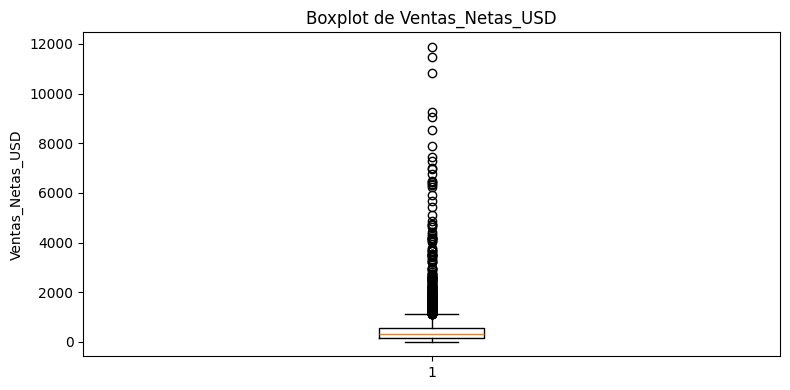

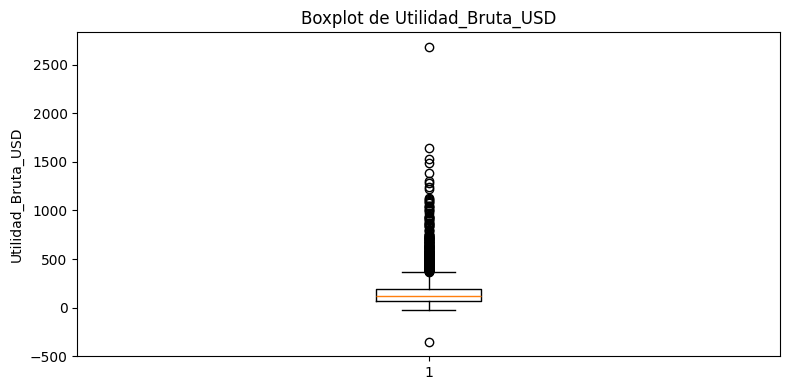

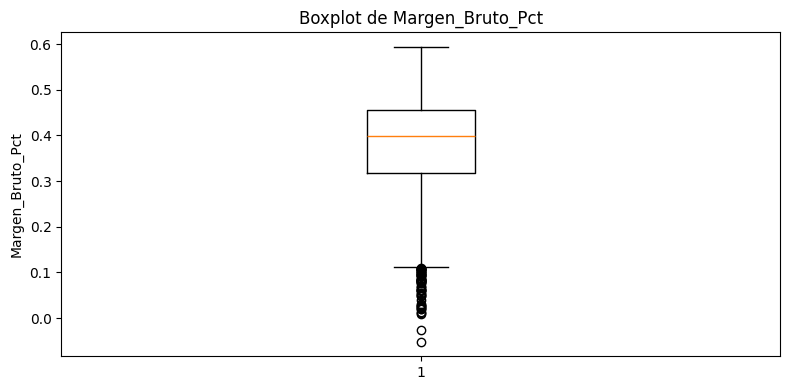

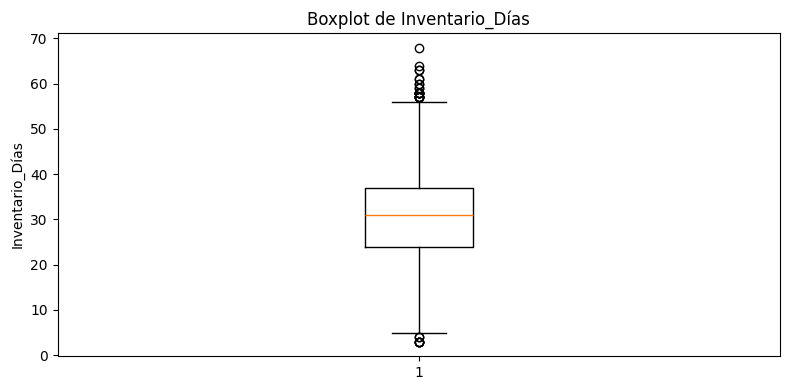

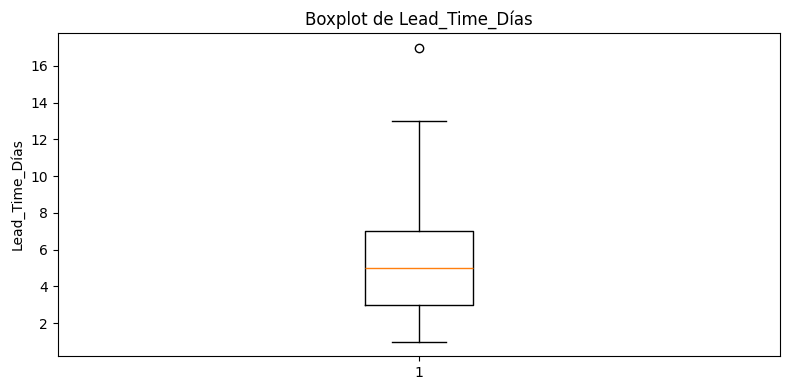

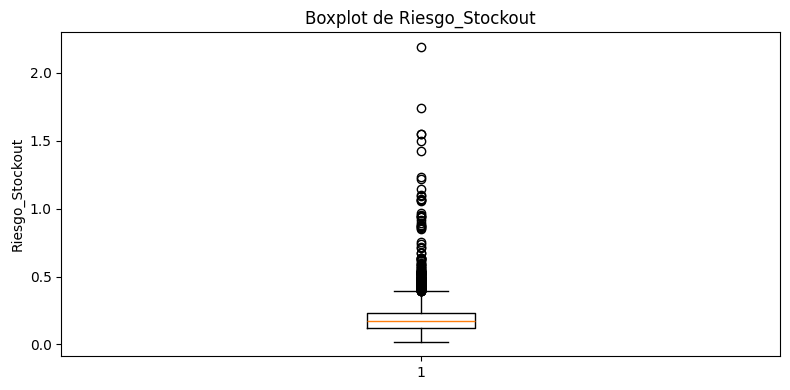

In [ ]:
# Boxplots de las principales variables

for columna in variables_descriptivas:

    plt.figure(figsize=(8, 4))

    plt.boxplot(
        df_descriptivo[columna].dropna()
    )

    plt.title(f"Boxplot de {columna}")
    plt.ylabel(columna)

    plt.tight_layout()
    plt.show()

### 12.5. Comparación por segmentos

Para relacionar la estadística descriptiva con los objetivos del proyecto, se comparan las principales variables según **tipo de institución, fabricante y región**.

Esta comparación permite identificar diferencias en ventas, rentabilidad y riesgo entre los diferentes segmentos del mercado farmacéutico.

De esta manera, la estadística descriptiva no solo permite conocer el comportamiento general de los datos, sino también identificar qué grupos presentan características diferenciadas que pueden ser relevantes para las decisiones comerciales y de abastecimiento.


In [ ]:
# Estadística descriptiva por tipo de institución

estadistica_institucion = (
    df_limpio
    .groupby("Tipo_Institución")
    [
        [
            "Ventas_Netas_USD",
            "Utilidad_Bruta_USD",
            "Margen_Bruto_Pct",
            "Riesgo_Stockout"
        ]
    ]
    .agg(["mean", "median", "std"])
)

display(estadistica_institucion.round(4))

Ventas_Netas_USD                      Utilidad_Bruta_USD  \
                                mean    median        std               mean   
Tipo_Institución                                                               
Cadena de Farmacias         325.8375   228.686   284.8409           117.3378   
Clínica                     342.5164  242.2745   292.6119            112.991   
Distribuidor               1084.4968  665.1218  1329.2225           297.5087   
Hospital                    428.1435  324.1703   347.6326            145.121   

                                        Margen_Bruto_Pct                  \
                       median       std             mean  median     std   
Tipo_Institución                                                           
Cadena de Farmacias   93.5116   84.4029           0.4061  0.4237  0.0945   
Clínica               92.0535   78.9599           0.3785  0.3977  0.1002   
Distribuidor         235.7565   236.442            0.346  0.3681  0.1059   
Hospital             119.7933  100.2556           0.3784  0.3975  0.0981   

                    Riesgo_Stockout                  
                               mean  median     std  
Tipo_Institución                                     
Cadena de Farmacias          0.1852   0.149  0.1697  
Clínica                      0.1888  0.1753  0.0961  
Distribuidor                 0.1996  0.1908  0.0704  
Hospital                     0.1879  0.1747  0.1006

In [ ]:
# Estadística descriptiva por fabricante

estadistica_fabricante = (
    df_limpio
    .groupby("Fabricante")
    [
        [
            "Ventas_Netas_USD",
            "Utilidad_Bruta_USD",
            "Margen_Bruto_Pct",
            "Riesgo_Stockout"
        ]
    ]
    .agg(["mean", "median", "std"])
)

display(estadistica_fabricante.round(4))

Ventas_Netas_USD                      Utilidad_Bruta_USD  \
                            mean    median        std               mean   
Fabricante                                                                 
Genfar                  423.2785  330.0077   329.5806           161.0907   
Laboratorios MK         749.0906  502.0994   725.4097           213.1419   
Procaps                 721.1104  410.1888  1033.2989            179.089   
Sanofi                  291.0319  241.5731   224.2588           119.8059   
Tecnoquímicas            374.161  312.9281   261.2345           149.4585   
Vitalis                 225.3037  164.4594   191.6257           107.2657   

                                    Margen_Bruto_Pct                  \
                   median       std             mean  median     std   
Fabricante                                                             
Genfar           122.8181  130.5009           0.3802  0.3881  0.0579   
Laboratorios MK  149.9011  188.8728           0.2998  0.3004  0.0609   
Procaps          134.2729  175.0985           0.3307  0.3505  0.1227   
Sanofi            97.6561   91.4878           0.4146  0.4152   0.047   
Tecnoquímicas     120.469   99.9686           0.4089  0.4143  0.0707   
Vitalis            80.097   89.7916           0.4811  0.4839  0.0421   

                Riesgo_Stockout                  
                           mean  median     std  
Fabricante                                       
Genfar                   0.1851  0.1667  0.1381  
Laboratorios MK          0.2589  0.2329  0.1454  
Procaps                  0.1918  0.1747  0.1181  
Sanofi                   0.1705  0.1602  0.0952  
Tecnoquímicas            0.1654  0.1514   0.097  
Vitalis                  0.1763  0.1666  0.0937

In [ ]:
# Estadística descriptiva por región

estadistica_region = (
    df_limpio
    .groupby("Región")
    [
        [
            "Ventas_Netas_USD",
            "Utilidad_Bruta_USD",
            "Margen_Bruto_Pct",
            "Inventario_Días",
            "Lead_Time_Días",
            "Riesgo_Stockout"
        ]
    ]
    .agg(["mean", "median", "std"])
)

display(estadistica_region.round(4))

Ventas_Netas_USD                     Utilidad_Bruta_USD            \
                      mean    median       std               mean    median   
Región                                                                        
Centro             554.395  368.0098   766.505           187.1528  142.9642   
Norte               431.97  272.8084  527.9881           132.8447   99.2817   
Occidente         550.8028  328.2583  819.4375           162.3121  121.3198   
Oriente           370.5864   237.823  478.5524           112.4221   87.4376   
Sur               495.5086  319.1446  651.4211           158.3616  118.8863   

                    Margen_Bruto_Pct                 Inventario_Días         \
                std             mean  median     std            mean median   
Región                                                                        
Centro     170.4865           0.3962  0.4146  0.0964         30.5892   30.0   
Norte      114.1247           0.3714  0.3934  0.1032         30.6910   30.0   
Occidente  148.7507           0.3712   0.394  0.1053         30.9496   31.0   
Oriente     92.3882           0.3709   0.389  0.0988         30.7236   31.0   
Sur        142.5129           0.3839  0.4029  0.0999         31.1083   31.0   

                   Lead_Time_Días                Riesgo_Stockout          \
               std           mean median     std            mean  median   
Región                                                                     
Centro      9.8238         5.1312    5.0  2.2862          0.1928  0.1747   
Norte       9.3869         5.0522    5.0  2.2927          0.1872  0.1705   
Occidente   9.7184         5.0663    5.0  2.3423          0.1852  0.1722   
Oriente    10.3137         5.1722    5.0  2.3753          0.1933  0.1753   
Sur         9.9659         5.0933    5.0  2.2669          0.1884  0.1718   

                   
              std  
Región             
Centro     0.1321  
Norte      0.1192  
Occidente  0.1052  
Oriente    0.1145  
Sur        0.1212

 # 13. Modelos aplicados

A partir de los resultados obtenidos en el análisis exploratorio y la estadística descriptiva, se aplican dos modelos de Machine Learning para profundizar en las dos dimensiones principales del proyecto: **rentabilidad** y **riesgo de desabastecimiento**. A su vez la aplicación de estos dos modelos ayuda a responder directamente a la pregunta principal del proyecto: qué tanto se relacionan el tipo de institución, el fabricante y la ubicación con la rentabilidad y el riesgo de desabastecimiento.

Para la rentabilidad se utiliza un modelo de regresión, debido a que el margen bruto es una variable numérica continua. Para el riesgo de desabastecimiento se utiliza un modelo de clasificación, transformando el riesgo continuo en una variable binaria de riesgo alto o bajo.

Los modelos serán evaluados mediante métricas acordes con cada tipo de problema y posteriormente se interpretarán sus resultados para determinar qué variables aportan mayor información para la toma de decisiones.


## 13.1. Selección del modelo y justificación

La selección de los modelos responde directamente a los objetivos del proyecto.

### Modelo 1 — Regresión para rentabilidad

Se selecciona un modelo de **regresión** para estudiar la rentabilidad, utilizando `Margen_Bruto_Pct` como variable objetivo. Esta variable es continua, por lo que un problema de regresión resulta apropiado.

Se comparan tres alternativas: **OLS, Ridge y Lasso**. OLS representa la regresión lineal sin regularización, mientras que Ridge y Lasso incorporan regularización para controlar posibles problemas de multicolinealidad y complejidad asociados principalmente con la transformación de variables categóricas mediante variables dummy.

Los predictores corresponden a características de la operación, institución, fabricante, ubicación y abastecimiento. Se excluyen precio, costo, ventas y utilidad bruta porque están directamente relacionados con el cálculo del margen y su utilización podría generar fuga de información (*data leakage*).

### Modelo 2 — Random Forest para riesgo de desabastecimiento

Para analizar el riesgo de desabastecimiento se selecciona un **Random Forest de clasificación**. La variable original `Riesgo_Stockout` es continua, por lo que se transforma en `Riesgo_Alto`, donde se clasifica cada operación como de riesgo alto o bajo utilizando la mediana como punto de corte.

Random Forest resulta adecuado porque permite trabajar con relaciones no lineales y combinaciones entre variables, además de proporcionar una medida de importancia de las variables utilizadas en la predicción.

De esta manera, los dos modelos permiten abordar de forma complementaria la pregunta principal del proyecto: la regresión analiza los factores asociados con la rentabilidad, mientras que Random Forest analiza la clasificación y los factores asociados con el riesgo de desabastecimiento.

## 13.2. Modelo 1 — Regresión para rentabilidad

El primer modelo busca explicar el comportamiento del `Margen_Bruto_Pct` a partir de características de la operación.

Se utilizarán variables relacionadas con el tipo de institución, fabricante, región, canal, línea terapéutica, inventario, tiempo de entrega, descuentos y devoluciones.

Las variables categóricas serán transformadas mediante One-Hot Encoding y las variables numéricas serán estandarizadas antes de entrenar los modelos.

In [ ]:
# ============================================================
# 13.2. MODELO 1 — REGRESIÓN PARA RENTABILIDAD
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Selección de variables
# ------------------------------------------------------------

target_1 = "Margen_Bruto_Pct"

cat_cols_1 = [
    "Tipo_Institución",
    "Fabricante",
    "Región",
    "Canal",
    "Línea_Terapéutica"
]

num_cols_1 = [
    "Inventario_Días",
    "Lead_Time_Días",
    "Descuento_Pct",
    "Devolución_Pct"
]

df_modelo1 = df_limpio[
    cat_cols_1 + num_cols_1 + [target_1]
].dropna()

X1 = df_modelo1[cat_cols_1 + num_cols_1]
y1 = df_modelo1[target_1]

print("Registros utilizados en Modelo 1:", len(df_modelo1))


# ------------------------------------------------------------
# 2. División entrenamiento / prueba
# ------------------------------------------------------------

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.20,
    random_state=42
)


# ------------------------------------------------------------
# 3. Preprocesamiento
# ------------------------------------------------------------

preprocesador_1 = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols_1
        ),
        (
            "num",
            StandardScaler(),
            num_cols_1
        )
    ]
)


# ------------------------------------------------------------
# 4. Modelos a comparar
# ------------------------------------------------------------

modelos_reg = {
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01)
}


# ------------------------------------------------------------
# 5. Entrenamiento y evaluación
# ------------------------------------------------------------

resultados_reg = []

for nombre, modelo in modelos_reg.items():

    pipeline = Pipeline([
        ("preprocesamiento", preprocesador_1),
        ("modelo", modelo)
    ])

    pipeline.fit(X1_train, y1_train)

    pred = pipeline.predict(X1_test)

    resultados_reg.append({
        "Modelo": nombre,
        "R²": r2_score(y1_test, pred),
        "MAE": mean_absolute_error(y1_test, pred),
        "RMSE": np.sqrt(
            mean_squared_error(y1_test, pred)
        )
    })


# ------------------------------------------------------------
# 6. Tabla comparativa
# ------------------------------------------------------------

resultados_reg_df = (
    pd.DataFrame(resultados_reg)
    .sort_values("R²", ascending=False)
    .reset_index(drop=True)
)

display(resultados_reg_df.round(4))

Registros utilizados en Modelo 1: 5007


,Modelo,R²,MAE,RMSE
0,OLS,0.7016,0.0454,0.0563
1,Ridge,0.7016,0.0454,0.0564
2,Lasso,0.3566,0.0670,0.0827


### 13.2.1. Evaluación del modelo de regresión

Para evaluar los modelos de regresión se utilizan tres métricas.

**R²:** mide la proporción de la variabilidad del margen bruto que es explicada por el modelo. Un valor más cercano a 1 indica una mayor capacidad explicativa.

**MAE:** representa el error absoluto promedio entre los valores reales y las predicciones. Mientras más cercano a 0, menor es el error promedio.

**RMSE:** mide el error de predicción y penaliza en mayor medida los errores grandes. Al igual que MAE, valores más cercanos a 0 representan un mejor desempeño.

El modelo seleccionado será aquel que presente el mejor equilibrio entre capacidad explicativa y error de predicción.

In [ ]:
# ============================================================
# 13.2.2. INTERPRETACIÓN DEL MEJOR MODELO
# ============================================================

mejor_modelo_nombre = resultados_reg_df.iloc[0]["Modelo"]

mejor_modelo = modelos_reg[mejor_modelo_nombre]

pipeline_final_reg = Pipeline([
    ("preprocesamiento", preprocesador_1),
    ("modelo", mejor_modelo)
])

pipeline_final_reg.fit(X1_train, y1_train)

print("Mejor modelo de regresión:", mejor_modelo_nombre)

Mejor modelo de regresión: OLS


In [ ]:
# ------------------------------------------------------------
# Coeficientes del modelo seleccionado
# ------------------------------------------------------------

nombres_features_reg = (
    pipeline_final_reg
    .named_steps["preprocesamiento"]
    .get_feature_names_out()
)

coeficientes = (
    pipeline_final_reg
    .named_steps["modelo"]
    .coef_
)

coef_df = pd.DataFrame({
    "Variable": nombres_features_reg,
    "Coeficiente": coeficientes
}).sort_values(
    "Coeficiente",
    ascending=False
)

print("Variables con mayor asociación positiva:")
display(coef_df.head(10))

print("Variables con mayor asociación negativa:")
display(coef_df.tail(10))

Variables con mayor asociación positiva:


,Variable,Coeficiente
20,cat__Línea_Terapéutica_Dolor y cuidado primario,0.092612
22,cat__Línea_Terapéutica_Respiratorio,0.086773
8,cat__Fabricante_Tecnoquímicas,0.048487
7,cat__Fabricante_Sanofi,0.037044
9,cat__Fabricante_Vitalis,0.034672
10,cat__Región_Centro,0.015952
19,cat__Línea_Terapéutica_Cardiometabólico,0.011381
23,cat__Línea_Terapéutica_Salud digestiva,0.009525
14,cat__Región_Sur,0.005266
3,cat__Tipo_Institución_Hospital,0.002745


Variables con mayor asociación negativa:


,Variable,Coeficiente
12,cat__Región_Occidente,-0.004855
11,cat__Región_Norte,-0.005169
13,cat__Región_Oriente,-0.011194
18,cat__Línea_Terapéutica_Antiinfecciosos,-0.016787
27,num__Descuento_Pct,-0.021952
24,cat__Línea_Terapéutica_Vacunas,-0.034117
5,cat__Fabricante_Laboratorios MK,-0.034117
6,cat__Fabricante_Procaps,-0.040631
4,cat__Fabricante_Genfar,-0.045455
21,cat__Línea_Terapéutica_Oncología,-0.149386


## 13.3. Modelo 2 — Random Forest para riesgo de desabastecimiento

El segundo modelo busca clasificar las operaciones según su nivel de riesgo de desabastecimiento.

La variable `Riesgo_Stockout` es originalmente continua, por lo que se transforma en una variable binaria denominada `Riesgo_Alto`. Se considera riesgo alto cuando el valor se encuentra en o por encima de la mediana de la variable.

Los predictores incluyen tipo de institución, fabricante, región, canal, línea terapéutica, inventario y lead time.

Se utiliza Random Forest porque permite capturar relaciones no lineales y, además, permite analizar la importancia relativa de las variables utilizadas para realizar las predicciones.

In [ ]:
# ============================================================
# 13.3. MODELO 2 — RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Preparar variable objetivo
# ------------------------------------------------------------

df_riesgo_modelo = df_limpio[
    df_limpio["Riesgo_Stockout"].between(0, 1)
].copy()

umbral = df_riesgo_modelo[
    "Riesgo_Stockout"
].median()

df_riesgo_modelo["Riesgo_Alto"] = (
    df_riesgo_modelo["Riesgo_Stockout"] >= umbral
).astype(int)

print(f"Umbral utilizado (mediana): {umbral:.2%}")

print("\nDistribución de clases:")
print(
    df_riesgo_modelo["Riesgo_Alto"]
    .value_counts(normalize=True)
    .sort_index()
)


# ------------------------------------------------------------
# 2. Selección de variables
# ------------------------------------------------------------

target_2 = "Riesgo_Alto"

cat_cols_2 = [
    "Tipo_Institución",
    "Fabricante",
    "Región",
    "Canal",
    "Línea_Terapéutica"
]

num_cols_2 = [
    "Inventario_Días",
    "Lead_Time_Días"
]

df_modelo2 = df_riesgo_modelo[
    cat_cols_2 + num_cols_2 + [target_2]
].dropna()

X2 = df_modelo2[
    cat_cols_2 + num_cols_2
]

y2 = df_modelo2[target_2]

print("\nRegistros utilizados en Modelo 2:", len(df_modelo2))


# ------------------------------------------------------------
# 3. División entrenamiento / prueba
# ------------------------------------------------------------

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42,
    stratify=y2
)


# ------------------------------------------------------------
# 4. Preprocesamiento
# ------------------------------------------------------------

preprocesador_2 = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols_2
        )
    ],
    remainder="passthrough"
)


# ------------------------------------------------------------
# 5. Random Forest
# ------------------------------------------------------------

rf_modelo = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)


# ------------------------------------------------------------
# 6. Pipeline
# ------------------------------------------------------------

pipeline_rf = Pipeline([
    ("preprocesamiento", preprocesador_2),
    ("modelo", rf_modelo)
])


# ------------------------------------------------------------
# 7. Entrenamiento
# ------------------------------------------------------------

pipeline_rf.fit(
    X2_train,
    y2_train
)


# ------------------------------------------------------------
# 8. Predicción
# ------------------------------------------------------------

pred_rf = pipeline_rf.predict(X2_test)


# ------------------------------------------------------------
# 9. Métricas de evaluación
# ------------------------------------------------------------

accuracy = accuracy_score(
    y2_test,
    pred_rf
)

precision = precision_score(
    y2_test,
    pred_rf,
    zero_division=0
)

recall = recall_score(
    y2_test,
    pred_rf,
    zero_division=0
)

f1 = f1_score(
    y2_test,
    pred_rf,
    zero_division=0
)

print("\nMÉTRICAS DE EVALUACIÓN")
print("----------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print(
    f"\nOOB Score: {rf_modelo.oob_score_:.4f}"
)


# ------------------------------------------------------------
# 10. Reporte completo
# ------------------------------------------------------------

print("\nREPORTE DE CLASIFICACIÓN")
print("------------------------")

print(
    classification_report(
        y2_test,
        pred_rf,
        target_names=[
            "Riesgo bajo",
            "Riesgo alto"
        ],
        zero_division=0
    )
)

Umbral utilizado (mediana): 17.29%

Distribución de clases:
Riesgo_Alto
0    0.5
1    0.5
Name: proportion, dtype: float64

Registros utilizados en Modelo 2: 4994

MÉTRICAS DE EVALUACIÓN
----------------------
Accuracy : 0.9710
Precision: 0.9608
Recall   : 0.9820
F1-score : 0.9713

OOB Score: 0.9662

REPORTE DE CLASIFICACIÓN
------------------------
              precision    recall  f1-score   support

 Riesgo bajo       0.98      0.96      0.97       500
 Riesgo alto       0.96      0.98      0.97       499

    accuracy                           0.97       999
   macro avg       0.97      0.97      0.97       999
weighted avg       0.97      0.97      0.97       999



### 13.3.1. Matriz de confusión

La matriz de confusión permite comparar las clasificaciones realizadas por el modelo con los valores reales.

En este proyecto resulta especialmente importante identificar correctamente las operaciones clasificadas como **riesgo alto**, ya que un falso negativo representa una operación que realmente presenta riesgo alto pero que el modelo clasificó como riesgo bajo.

Por esta razón, además de Accuracy, se analizarán Precision, Recall y F1-score, prestando especial atención al **Recall de la clase de riesgo alto**.


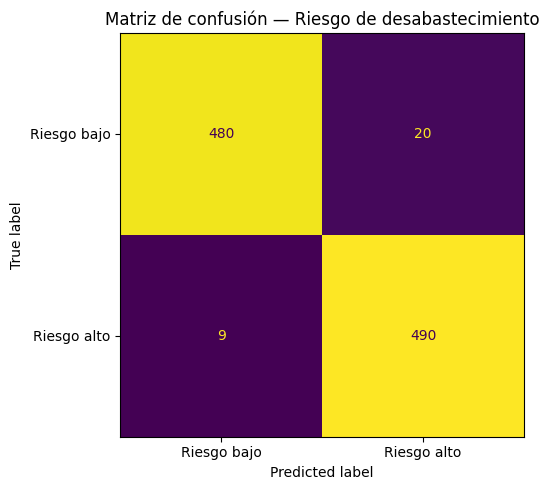

In [ ]:
# ============================================================
# MATRIZ DE CONFUSIÓN
# ============================================================

matriz = confusion_matrix(
    y2_test,
    pred_rf
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=[
        "Riesgo bajo",
        "Riesgo alto"
    ]
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

ax.set_title(
    "Matriz de confusión — Riesgo de desabastecimiento"
)

plt.tight_layout()
plt.show()

### 13.3.2. Importancia de las variables

Una ventaja adicional de Random Forest es que permite obtener una medida de la importancia de las variables utilizadas por el modelo.

Esta información permite identificar qué características tienen mayor peso en la clasificación del riesgo de desabastecimiento.

Las variables con mayor importancia deben interpretarse como variables relevantes para la **predicción** del riesgo y no necesariamente como causas directas del desabastecimiento.


In [ ]:
# ============================================================
# IMPORTANCIA DE VARIABLES
# ============================================================

nombres_features_rf = (
    pipeline_rf
    .named_steps["preprocesamiento"]
    .get_feature_names_out()
)

importancias = (
    pipeline_rf
    .named_steps["modelo"]
    .feature_importances_
)

importancia_df = pd.DataFrame({
    "Variable": nombres_features_rf,
    "Importancia": importancias
}).sort_values(
    "Importancia",
    ascending=False
)

display(
    importancia_df.head(15).round(4)
)

,Variable,Importancia
26,remainder__Lead_Time_Días,0.5550
25,remainder__Inventario_Días,0.2885
24,cat__Línea_Terapéutica_Vacunas,0.0211
5,cat__Fabricante_Laboratorios MK,0.0196
17,cat__Canal_Retail,0.0137
0,cat__Tipo_Institución_Cadena de Farmacias,0.0115
2,cat__Tipo_Institución_Distribuidor,0.0109
16,cat__Canal_Mayorista,0.0097
15,cat__Canal_Institucional,0.0084
21,cat__Línea_Terapéutica_Oncología,0.0062


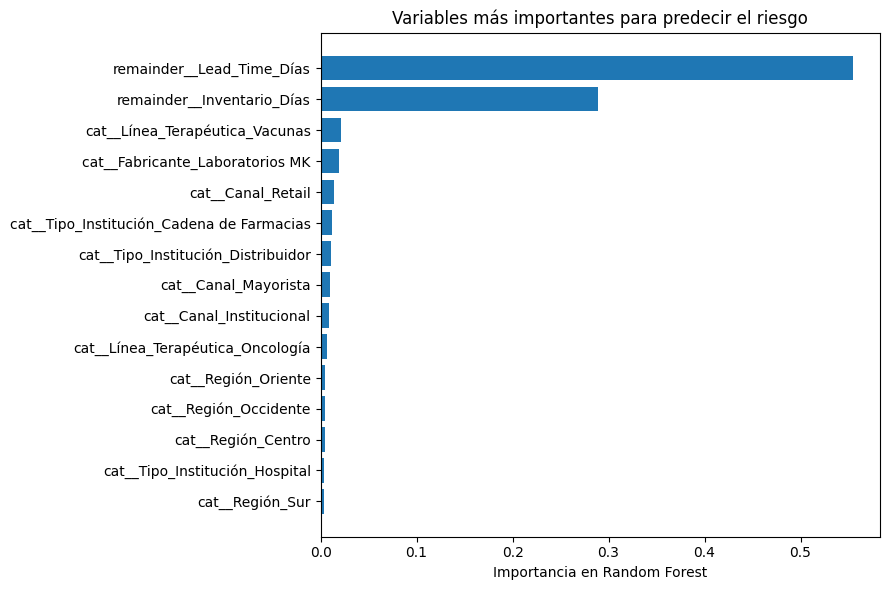

In [ ]:
# ------------------------------------------------------------
# Gráfico de las 15 variables más importantes
# ------------------------------------------------------------

top_importancia = (
    importancia_df
    .head(15)
    .sort_values("Importancia")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_importancia["Variable"],
    top_importancia["Importancia"]
)

plt.title(
    "Variables más importantes para predecir el riesgo"
)

plt.xlabel(
    "Importancia en Random Forest"
)

plt.tight_layout()
plt.show()

## 13.4. Interpretación comparativa de los modelos

Los dos modelos aplicados permiten analizar las dos dimensiones principales del proyecto: la **rentabilidad** y el **riesgo de desabastecimiento**. Debido a que cada problema tiene una naturaleza diferente, los modelos fueron evaluados con métricas específicas para regresión y clasificación.

### Modelo de regresión — Rentabilidad

Para predecir `Margen_Bruto_Pct` se compararon tres modelos: OLS, Ridge y Lasso.

Los resultados muestran que **OLS y Ridge presentan prácticamente el mismo desempeño**, con un R² de **0,7016**, un MAE de **0,0454** y un RMSE de aproximadamente **0,056**. Esto indica que ambos modelos explican cerca del **70,16% de la variabilidad observada en el margen bruto**, manteniendo un error de predicción relativamente bajo.

Por otro lado, Lasso presenta un desempeño inferior, con un R² de **0,3566**, un MAE de **0,0670** y un RMSE de **0,0827**. Por lo tanto, para este conjunto de datos, la regularización utilizada por Lasso reduce considerablemente la capacidad explicativa del modelo.

Debido a que OLS presenta el mayor R² junto con el menor MAE y RMSE, se selecciona **OLS como el modelo de regresión final**.

### Modelo Random Forest — Riesgo de desabastecimiento

Para el riesgo de desabastecimiento se utilizó Random Forest como modelo de clasificación. La variable `Riesgo_Stockout` fue transformada en una clasificación de riesgo bajo y alto utilizando la mediana de **17,29%** como punto de corte.

El modelo obtuvo un **Accuracy de 97,10%**, una **Precision de 96,08%**, un **Recall de 98,20%** y un **F1-score de 97,13%**. Estos resultados muestran una elevada capacidad para distinguir entre operaciones de riesgo bajo y alto.

La matriz de confusión muestra **480 verdaderos negativos, 20 falsos positivos, 9 falsos negativos y 490 verdaderos positivos**. En particular, el modelo identifica correctamente 490 de las 499 operaciones que realmente pertenecen a la categoría de riesgo alto.

El **Recall de 98,20% para riesgo alto** es especialmente relevante para el proyecto, ya que indica que el modelo logra identificar la gran mayoría de las operaciones que realmente presentan un nivel de riesgo alto.

Además, el análisis de importancia de variables muestra que **Lead_Time_Días** es la variable con mayor importancia para la clasificación, seguida por **Inventario_Días**. Las variables categóricas presentan una importancia considerablemente menor en comparación con estas dos variables.

### Comparación general

Los modelos no deben compararse directamente por sus métricas, ya que resuelven problemas diferentes. El modelo OLS realiza una **predicción numérica del margen bruto**, mientras que Random Forest realiza una **clasificación del nivel de riesgo**.

En conjunto, los resultados indican que existe una capacidad importante para explicar la variabilidad de la rentabilidad mediante las variables seleccionadas y una capacidad muy alta para clasificar el riesgo de desabastecimiento.

Estos resultados permiten pasar de un análisis descriptivo a un análisis predictivo, aportando evidencia cuantitativa para apoyar decisiones relacionadas con la rentabilidad y la gestión del abastecimiento.

#Conclusiones

###Calidad de los Datos y Diagnóstico Inicial:

- El análisis del dataset de operaciones farmacéuticas colombianas del año 2025 (5,075 registros iniciales) evidenció la presencia de inconsistencias de formato y calidad de datos, tales como duplicados exactos (50 registros), valores faltantes en campos clave (Institución, Fabricante, Ciudad, Región, entre otros) e inconsistencias en la estandarización de variables categóricas (como diferencias en mayúsculas, minúsculas y tildes en Tipo_Institución y Ciudad).

- La corrección y estandarización de estos aspectos en la etapa de preparación de datos resulta indispensable para garantizar la consistencia en el cálculo numérico de las variables operativas y financieras (ventas, utilidad y riesgo de stockout).


###Comportamiento Comercial y Rentabilidad:

- La estructura del mercado muestra una concentración considerable de transacciones en canales institucionales como Cadenas de Farmacias y Hospitales. Asimismo, fabricantes como Procaps, Genfar y Vitalis representan una proporción significativa del volumen total de operaciones analizadas.

- La evaluación del margen bruto y la utilidad bruta en relación con las ventas netas permite identificar qué tipos de institución y canales ofrecen mayor retorno operativo, diferenciando los segmentos puramente voluminosos de aquellos que generan mayor margen comercial por transacción.

###Logística, Abastecimiento y Riesgo de Stockout:

- Se identificó que variables logísticas clave como el tiempo de entrega (Lead Time) y los días de inventario (Inventario_Días) guardan una relación directa con la variabilidad del riesgo de desabastecimiento (Riesgo_Stockout).

- Los registros que combinan niveles reducidos de inventario disponible junto con prolongaciones en el Lead Time tienden a registrar mayores niveles de riesgo y urgencia de abasto, impactando de forma directa la continuidad del servicio a los pacientes.

###Implicaciones para la Toma de Decisiones:

- Los hallazgos proporcionan un marco cuantitativo para priorizar decisiones de inventario y compras, recomendando focalizar estrategias de amortiguamiento (stock de seguridad) en aquellas líneas terapéuticas o regiones con mayor riesgo de desabastecimiento y alto volumen de pacientes impactados.

- La segmentación por desempeño financiero y nivel de riesgo abastece una herramienta analítica clave para optimizar la rentabilidad comercial sin comprometer la disponibilidad del producto en el sector salud.

#Referencias

- Villamil, D. (2024). Dataset farmacéutico Colombia. GitHub. https://github.com/dvillamil857/dataset-farmaceutico-colombia

- Ministerio de Salud y Protección Social de Colombia. (2020). Política Farmacéutica Nacional: Avances y desafíos en el acceso y sostenibilidad. Bogotá D.C.: Minsalud.

- Organización Panamericana de la Salud (OPS). (2021). Gestión de la cadena de suministro de medicamentos y tecnologías sanitarias en América Latina. Washington, D.C.: OPS.

- McKinsey & Company. (2023). Supply chain resilience in the pharmaceutical industry: Balancing risk and profitability. Pharma & Life Sciences Insights.

- Chopra, S., & Meindl, P. (2016). Supply Chain Management: Strategy, Planning, and Operation (6.ª ed.). Pearson.

- Pandas Development Team. (2024). pandas-dev/pandas: Pandas 2.2.0. Zenodo. https://doi.org/10.5281/zenodo.3509134